In [1]:
import numpy as np
import matplotlib.pyplot as plt
#import matplotlib.cm as cm

import pandas as pd
import seaborn as sns
import sklearn
from sklearn import linear_model as lm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE, VarianceThreshold

## Import Data

In [2]:
# Create master dataframe

# 1. Find all CSVs
import os
import glob

#folder_path = '/Users/ey3722/Downloads/del_data/'
folder_path = '/Users/erinyoo/Downloads/del_data/'
csv_files = glob.glob(os.path.join(folder_path, f"*.csv"))


# 2. Create master dataframe
bts_ds = pd.DataFrame()

for file in csv_files:
    df = pd.read_csv(file, dtype={'CANCELLATION_CODE': str})

    # Append CSV file to master dataframe
    bts_ds = pd.concat([bts_ds, df], ignore_index=True)


# 3. Add binary information
bts_ds['IS_DELAYED'] = bts_ds['ARR_DELAY'] > 15
bts_ds['IS_CARRIER_DELAY'] = bts_ds['CARRIER_DELAY'] > 15
bts_ds['IS_WEATHER_DELAY'] = bts_ds['WEATHER_DELAY'] > 15
bts_ds['IS_NAS_DELAY'] = bts_ds['NAS_DELAY'] > 15
bts_ds['IS_SECURITY_DELAY'] = bts_ds['SECURITY_DELAY'] > 15
bts_ds['IS_LATE_AIRCRAFT_DELAY'] = bts_ds['LATE_AIRCRAFT_DELAY'] > 15

In [4]:
bts_ds

,YEAR,MONTH,OP_UNIQUE_CARRIER,ORIGIN_AIRPORT_ID,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST_AIRPORT_ID,DEST_CITY_NAME,DEST_STATE_ABR,DEP_DELAY,...,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,IS_DELAYED,IS_CARRIER_DELAY,IS_WEATHER_DELAY,IS_NAS_DELAY,IS_SECURITY_DELAY,IS_LATE_AIRCRAFT_DELAY
0,2024,2,9E,10135,"Allentown/Bethlehem/Easton, PA",PA,10397,"Atlanta, GA",GA,NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
1,2024,2,9E,10135,"Allentown/Bethlehem/Easton, PA",PA,10397,"Atlanta, GA",GA,-18.0,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
2,2024,2,9E,10135,"Allentown/Bethlehem/Easton, PA",PA,10397,"Atlanta, GA",GA,-16.0,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
3,2024,2,9E,10135,"Allentown/Bethlehem/Easton, PA",PA,10397,"Atlanta, GA",GA,-12.0,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
4,2024,2,9E,10135,"Allentown/Bethlehem/Easton, PA",PA,10397,"Atlanta, GA",GA,-11.0,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93900894,2013,8,YV,15412,"Knoxville, TN",TN,11057,"Charlotte, NC",NC,55.0,...,0.0,0.0,0.0,35.0,True,False,False,False,False,True
93900895,2013,8,YV,15412,"Knoxville, TN",TN,11057,"Charlotte, NC",NC,69.0,...,0.0,0.0,0.0,50.0,True,False,False,False,False,True
93900896,2013,8,YV,15412,"Knoxville, TN",TN,11057,"Charlotte, NC",NC,107.0,...,0.0,0.0,0.0,107.0,True,False,False,False,False,True
93900897,2013,8,YV,16218,"Yuma, AZ",AZ,14107,"Phoenix, AZ",AZ,3.0,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False


In [5]:
bts_ds.columns

Index(['YEAR', 'MONTH', 'OP_UNIQUE_CARRIER', 'ORIGIN_AIRPORT_ID',
       'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'DEST_AIRPORT_ID',
       'DEST_CITY_NAME', 'DEST_STATE_ABR', 'DEP_DELAY', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CARRIER_DELAY',
       'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
       'IS_DELAYED', 'IS_CARRIER_DELAY', 'IS_WEATHER_DELAY', 'IS_NAS_DELAY',
       'IS_SECURITY_DELAY', 'IS_LATE_AIRCRAFT_DELAY'],
      dtype='object')

### Dictionaries for Carrier & Airport Codes

In [ ]:
# ChatGPT formatted these dictionaries based on my results

# Carriers
airline_codes = {
    '9E': 'Endeavor Air',
    'AA': 'American Airlines',
    'AS': 'Alaska Airlines',
    'B6': 'JetBlue Airways',
    'CO': 'Continental Airlines',  # Note: Merged with United Airlines
    'DL': 'Delta Air Lines',
    'EV': 'ExpressJet Airlines',
    'F9': 'Frontier Airlines',
    'FL': 'AirTran Airways',  # Note: Merged with Southwest Airlines
    'G4': 'Allegiant Air',
    'HA': 'Hawaiian Airlines',
    'MQ': 'Envoy Air',
    'NK': 'Spirit Airlines',
    'OH': 'Comair',  # Note: Defunct
    'OO': 'SkyWest Airlines',
    'QX': 'Horizon Air',
    'UA': 'United Airlines',
    'US': 'US Airways',  # Note: Merged with American Airlines
    'VX': 'Virgin America',  # Note: Merged with Alaska Airlines
    'WN': 'Southwest Airlines',
    'XE': 'ExpressJet Airlines',
    'YV': 'Mesa Air Group',
    'YX': 'Republic Airways'
}

# Top 40 Airports
airport_abbreviations = {
    16133: 'ORD',  # Chicago O'Hare International Airport
    13282: 'LAX',  # Los Angeles International Airport
    11495: 'SFO',  # San Francisco International Airport
    14222: 'JFK',  # New York John F. Kennedy International Airport
    13964: 'DEN',  # Denver International Airport
    10930: 'DFW',  # Dallas/Fort Worth International Airport
    11726: 'SEA',  # Seattle-Tacoma International Airport
    12119: 'MIA',  # Miami International Airport
    10917: 'BOS',  # Boston Logan International Airport
    14716: 'PHX',  # Phoenix Sky Harbor International Airport
    12223: 'MCO',  # Orlando International Airport
    12917: 'LAS',  # Las Vegas McCarran International Airport
    10676: 'SAN',  # San Diego International Airport
    12544: 'ATL',  # Atlanta Hartsfield-Jackson International Airport
    12250: 'IAD',  # Washington Dulles International Airport
    13388: 'MDW',  # Chicago Midway International Airport
    12320: 'MSP',  # Minneapolis-Saint Paul International Airport
    15497: 'DTW',  # Detroit Metropolitan Airport
    10617: 'SLC',  # Salt Lake City International Airport
    13541: 'CLT',  # Charlotte Douglas International Airport
    10157: 'PHL',  # Philadelphia International Airport
    11002: 'IAH',  # Houston George Bush Intercontinental Airport
    13829: 'MCI',  # Kansas City International Airport
    13424: 'CLE',  # Cleveland Hopkins International Airport
    11027: 'STL',  # St. Louis Lambert International Airport
    10372: 'BWI',  # Baltimore/Washington International Thurgood Marshall Airport
    13832: 'SDF',  # Louisville Muhammad Ali International Airport
    14259: 'IND',  # Indianapolis International Airport
    13203: 'CMH',  # Columbus John Glenn International Airport
    14314: 'PIT',  # Pittsburgh International Airport
    10154: 'TPA',  # Tampa International Airport
    15008: 'PDX',  # Portland International Airport
    14877: 'RDU',  # Raleigh-Durham International Airport
    14512: 'SMF',  # Sacramento International Airport
    13983: 'SLC',  # Salt Lake City International Airport
    15454: 'SAT',  # San Antonio International Airport
    11283: 'SJC',  # San Jose International Airport
    10590: 'SNA',  # Santa Ana John Wayne Airport
    12265: 'SEA',  # Seattle-Tacoma International Airport
    13241: 'STL',   # St. Louis Lambert International Airport
    12365: 'EWR',  # Newark Liberty International Airport
    14082: 'SFO',  # San Francisco International Airport
    14761: 'PHX',  # Phoenix Sky Harbor International Airport
    10732: 'BHM',  # Birmingham-Shuttlesworth International Airport
    14254: 'IND',  # Indianapolis International Airport
    15356: 'TTN',  # Trenton Mercer Airport
    14092: 'SJC',  # San Jose International Airport
    10466: 'HSV',  # Huntsville International Airport
    14112: 'HSV',  # Huntsville International Airport
    12559: 'SNA',  # John Wayne Airport (Santa Ana)
    13459: 'MKE',  # General Mitchell International Airport
    14802: 'MSY',  # Louis Armstrong New Orleans International Airport
    11618: 'EWR',  # Newark Liberty International Airport
    15070: 'SWF',  # Stewart International Airport
    14487: 'RDU',  # Raleigh-Durham International Airport
    11076: 'SJC',  # San Jose International Airport
    12197: 'HPN',  # Westchester County Airport
    14025: 'PBI',  # Palm Beach International Airport
    11503: 'DCA'   # Ronald Reagan Washington National Airport
}

airport_abv_to_code = {v: k for k, v in airport_abbreviations.items()}

## Get Counts for
* Arrival delay
* Carrier delay
* Weather delay
* NAS delay
* Security delay
* Late aircraft delay

In [44]:
ARR_DELAY_CT = (bts_ds['ARR_DELAY'] > 0.0)
CARRIER_DELAY_CT = (bts_ds['CARRIER_DELAY'] > 0.0)
WEATHER_DELAY_CT = (bts_ds['WEATHER_DELAY'] > 0.0)
NAS_DELAY_CT = (bts_ds['NAS_DELAY'] > 0.0)
SECURITY_DELAY_CT = (bts_ds['SECURITY_DELAY'] > 0.0)
LATE_AIRCRAFT_DELAY_CT = (bts_ds['LATE_AIRCRAFT_DELAY'] > 0.0)

print("ARR_DELAY_CT:", np.sum(ARR_DELAY_CT), 
      "CARRIER_DELAY_CT:", np.sum(CARRIER_DELAY_CT),
      "WEATHER_DELAY_CT:", np.sum(WEATHER_DELAY_CT),
      "NAS_DELAY_CT:", np.sum(NAS_DELAY_CT),
      "SECURITY_DELAY_CT:", np.sum(SECURITY_DELAY_CT),
      "LATE_AIRCRAFT_DELAY_CT:", np.sum(LATE_AIRCRAFT_DELAY_CT))

ARR_DELAY_CT: 4994538 CARRIER_DELAY_CT: 1576855 WEATHER_DELAY_CT: 160904 NAS_DELAY_CT: 1386610 SECURITY_DELAY_CT: 15554 LATE_AIRCRAFT_DELAY_CT: 1454333


In [ ]:
# Sanity Check
print("delay count:", np.sum(ARR_DELAY_CT), "no delay:", np.sum(bts_ds['ARR_DELAY'].isna() | bts_ds['ARR_DELAY'] == 0))
print(np.sum(bts_ds['ARR_DELAY'].isna() | bts_ds['ARR_DELAY'] == 0))
print(np.sum(bts_ds['ARR_DELAY'] == 0))
print(np.sum(bts_ds['ARR_DELAY'].isna()))
print(np.sum(bts_ds['ARR_DELAY'] > 0.0))

## By Year

YEAR
2010    17.465296
2011    17.504155
2012    15.965590
2013    19.152107
2014    20.511061
2015    17.588660
2016    16.530163
2017    17.488745
2018    18.104867
2019    18.092944
2020     8.815866
2021    16.239225
2022    19.776390
2023    19.563329
2024    19.824438
Name: IS_DELAYED, dtype: float64


Text(0.5, 0, 'Year')

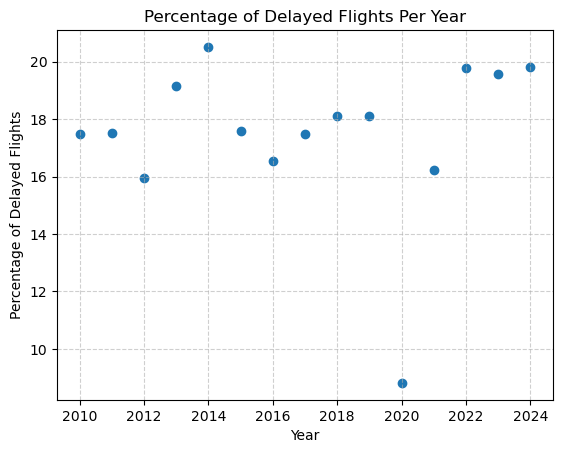

In [7]:
# Calculate the percentage of delayed flights per year
delayed_percentage = bts_ds.groupby('YEAR')['IS_DELAYED'].mean() * 100

# Display the result
print(delayed_percentage)

plt.scatter(np.arange(2010,2025), delayed_percentage)
plt.grid(True, alpha=0.6, linestyle='--')
plt.ylabel('Percentage of Delayed Flights')
plt.title('Percentage of Delayed Flights Per Year')
plt.xlabel('Year')

Text(0.5, 0, 'Month')

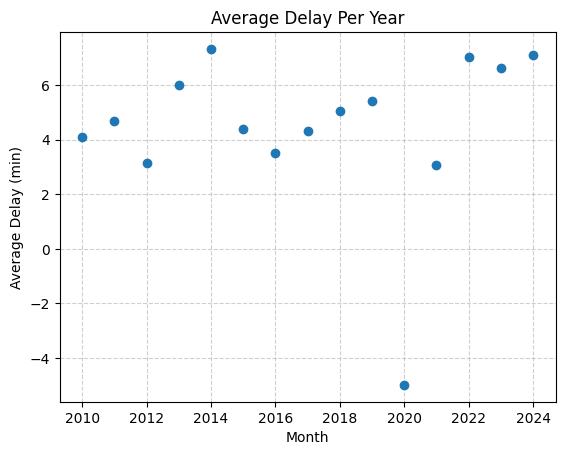

In [5]:
avg_del_year = bts_ds.groupby('YEAR')['ARR_DELAY'].mean()

# Plot
plt.plot(avg_del_year.index, avg_del_year.values, "o")
plt.grid(True, alpha=0.6, linestyle='--')
plt.ylabel('Average Delay (min)')
plt.title('Average Delay Per Year')
plt.xlabel('Month')

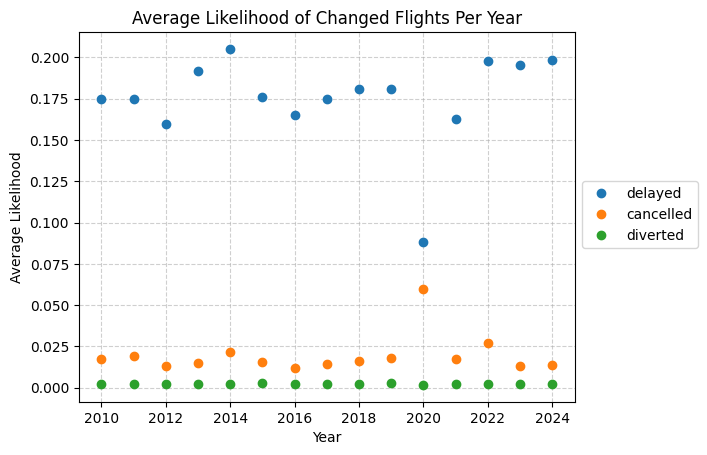

In [6]:
# Average XYZ flights per year

avg_del_month = bts_ds.groupby('YEAR')['IS_DELAYED'].mean()
avg_canc_month = bts_ds.groupby('YEAR')['CANCELLED'].mean()
avg_div_month = bts_ds.groupby('YEAR')['DIVERTED'].mean()

# Plot
fig, ax = plt.subplots()
ax.plot(avg_del_month.index, avg_del_month.values, "o", label='delayed')
ax.plot(avg_canc_month.index, avg_canc_month.values, "o", label='cancelled')
ax.plot(avg_del_month.index, avg_div_month.values, "o", label='diverted')

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Likelihood')
ax.set_title('Average Likelihood of Changed Flights Per Year')
ax.set_xlabel('Year')

fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

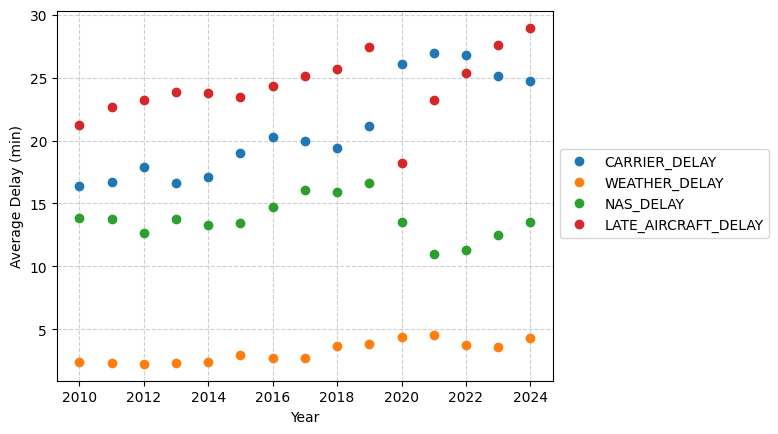

In [7]:
# Average delayed time per reason for delays per month

reasons = ['CARRIER_DELAY', 'WEATHER_DELAY',	'NAS_DELAY', 'LATE_AIRCRAFT_DELAY']   # 'SECURITY_DELAY' not included because all zeroes

fig, ax = plt.subplots()

for reason in reasons:
  avg_del_reason_month = bts_ds.groupby('YEAR')[reason].mean()
  ax.plot(avg_del_reason_month.index, avg_del_reason_month.values, "o", label=reason)


ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_xlabel('Year')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

## By Month

MONTH
1     17.735613
2     17.315893
3     16.888692
4     16.602291
5     18.063203
6     21.820096
7     21.827806
8     19.194150
9     14.124164
10    14.414341
11    14.143733
12    19.842177
Name: IS_DELAYED, dtype: float64


Text(0.5, 0, 'Month')

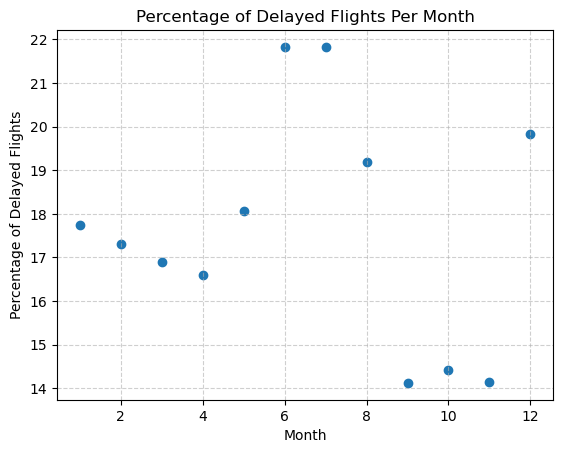

In [9]:
# Calculate the percentage of delayed flights per month
delayed_percentage = bts_ds.groupby('MONTH')['IS_DELAYED'].mean() * 100

# Display the result
print(delayed_percentage)

plt.scatter(np.arange(1,13), delayed_percentage)
plt.grid(True, alpha=0.6, linestyle='--')
plt.ylabel('Percentage of Delayed Flights')
plt.title('Percentage of Delayed Flights Per Month')
plt.xlabel('Month')

Text(0.5, 0, 'Month')

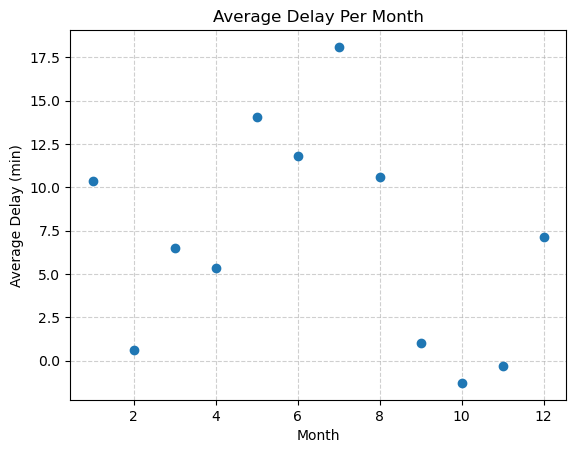

In [7]:
# Average delay per month

avg_del_month = bts_ds.groupby('MONTH')['ARR_DELAY'].mean()

# Plot
fig, ax = plt.subplots()
ax.plot(avg_del_month.index, avg_del_month.values, "o")

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Month')
ax.set_xlabel('Month')

Text(0.5, 0, 'Month')

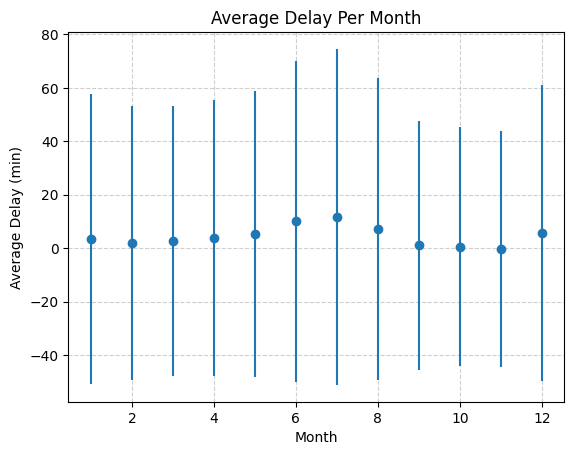

In [60]:
# Average delay per month with error bars

avg_del_month = bts_ds.groupby('MONTH')['ARR_DELAY'].mean()
errs = bts_ds.groupby('MONTH')['ARR_DELAY'].std()

# Plot
fig, ax = plt.subplots()
ax.errorbar(avg_del_month.index, avg_del_month.values, errs, fmt='o')

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Month')
ax.set_xlabel('Month')

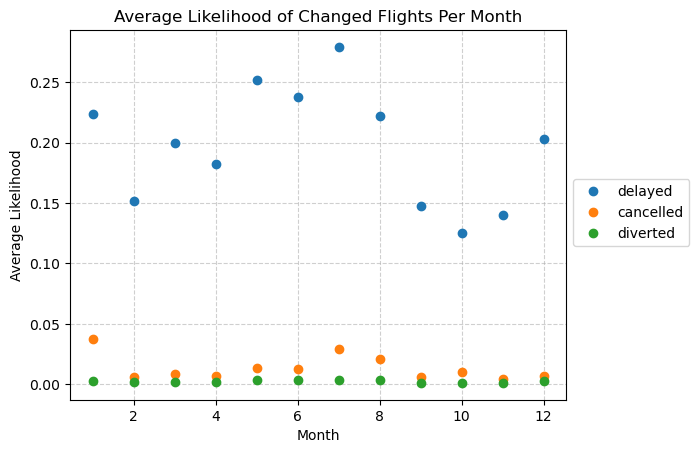

In [8]:
# Average XYZ flights per month

avg_del_month = bts_ds.groupby('MONTH')['IS_DELAYED'].mean()
avg_canc_month = bts_ds.groupby('MONTH')['CANCELLED'].mean()
avg_div_month = bts_ds.groupby('MONTH')['DIVERTED'].mean()

# Plot
fig, ax = plt.subplots()
ax.plot(avg_del_month.index, avg_del_month.values, "o", label='delayed')
ax.plot(avg_canc_month.index, avg_canc_month.values, "o", label='cancelled')
ax.plot(avg_del_month.index, avg_div_month.values, "o", label='diverted')

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Likelihood')
ax.set_title('Average Likelihood of Changed Flights Per Month')
ax.set_xlabel('Month')

fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

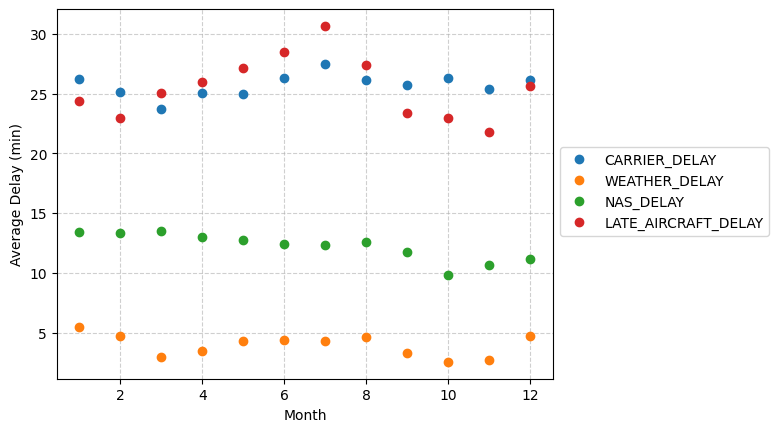

In [61]:
# Average delayed time per reason for delays per month

reasons = ['CARRIER_DELAY', 'WEATHER_DELAY',	'NAS_DELAY', 'LATE_AIRCRAFT_DELAY']   # 'SECURITY_DELAY' not included because all zeroes

fig, ax = plt.subplots()

for reason in reasons:
  avg_del_reason_month = bts_ds.groupby('MONTH')[reason].mean()
  ax.plot(avg_del_reason_month.index, avg_del_reason_month.values, "o", label=reason)


ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_xlabel('Month')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

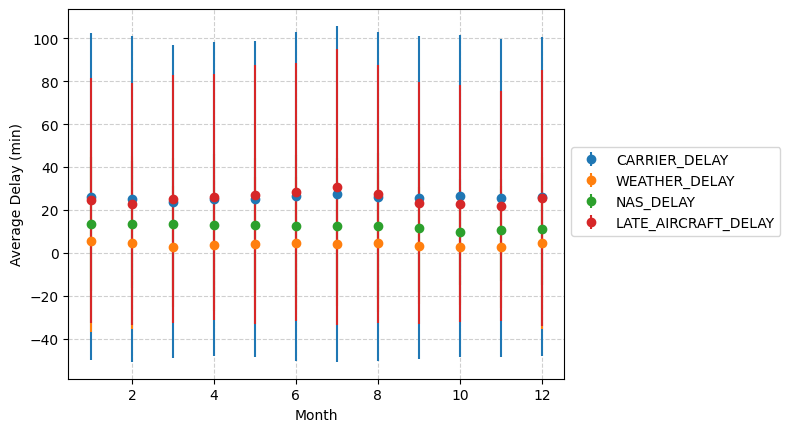

In [62]:
# Average delayed time per reason for delays per month with error bars

reasons = ['CARRIER_DELAY', 'WEATHER_DELAY',	'NAS_DELAY', 'LATE_AIRCRAFT_DELAY']   # 'SECURITY_DELAY' not included because all zeroes

fig, ax = plt.subplots()

for reason in reasons:
  avg_del_reason_month = bts_ds.groupby('MONTH')[reason].mean()
  errs = bts_ds.groupby('MONTH')[reason].std()

  ax.errorbar(avg_del_reason_month.index, avg_del_reason_month.values, errs, fmt="o", label=reason)


ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_xlabel('Month')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

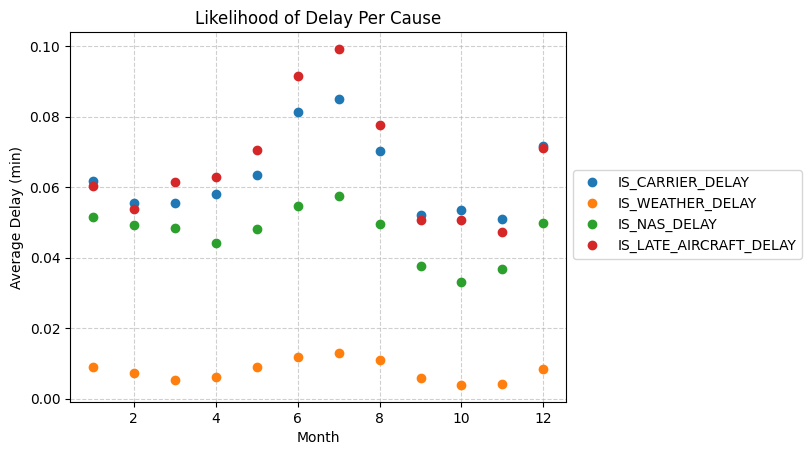

In [63]:
# Average likelihood of getting delayed per reason for delays per month

reasons = ['IS_CARRIER_DELAY', 'IS_WEATHER_DELAY',	'IS_NAS_DELAY', 'IS_LATE_AIRCRAFT_DELAY']   # 'IS_SECURITY_DELAY' not included because all zeroes

fig, ax = plt.subplots()

for reason in reasons:
  avg_del_reason_month = bts_ds.groupby('MONTH')[reason].mean()

  ax.plot(avg_del_reason_month.index, avg_del_reason_month.values, "o", label=reason)

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_title('Likelihood of Delay Per Cause')
ax.set_ylabel('Average Delay (min)')
ax.set_xlabel('Month')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

## By Carrier

In [9]:
np.unique(bts_ds['OP_UNIQUE_CARRIER'])

array(['9E', 'AA', 'AS', 'B6', 'CO', 'DL', 'EV', 'F9', 'FL', 'G4', 'HA',
       'MQ', 'NK', 'OH', 'OO', 'QX', 'UA', 'US', 'VX', 'WN', 'XE', 'YV',
       'YX'], dtype=object)

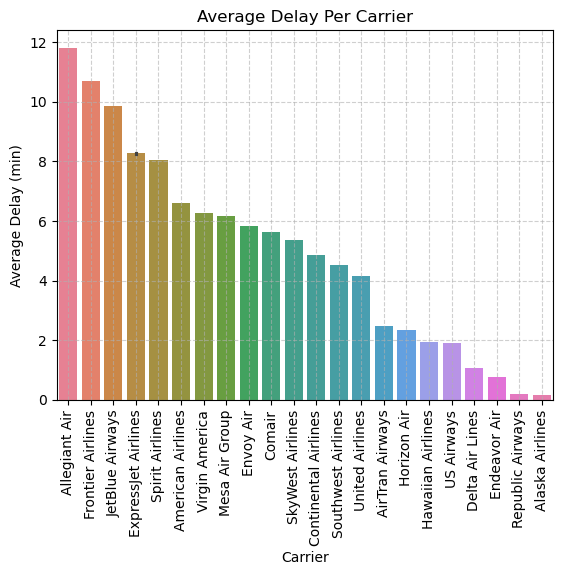

In [34]:
# Average delay per carrier

avg_del_carrier = bts_ds.groupby('OP_UNIQUE_CARRIER')['ARR_DELAY'].mean()

df = avg_del_carrier.reset_index() # reset_index to transpose into desired format for seaborn barplot
df = df.sort_values(by='ARR_DELAY', ascending=False)
df['CARRIER_ABV'] = df['OP_UNIQUE_CARRIER'].map(airline_codes)

# Plot
fig, ax = plt.subplots()
sns.barplot(data=df, x='CARRIER_ABV', y='ARR_DELAY', hue='CARRIER_ABV')

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Carrier')
ax.set_xlabel('Carrier')

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels


In [35]:
df['ARR_DELAY'][:-1]

9     11.810566
7     10.704608
3      9.853549
6      8.286283
20     8.238371
12     8.036908
1      6.586102
18     6.272490
21     6.163956
11     5.844464
13     5.630342
14     5.356423
4      4.861764
19     4.512206
16     4.147331
8      2.468946
15     2.344420
10     1.940729
17     1.896087
5      1.079422
0      0.773563
22     0.204573
Name: ARR_DELAY, dtype: float64

In [28]:
meanness = [4/8, 6/8, 2/8, 0, 4/8, 3/8, 0, 0, 0, 0, 0, 0, 3/8, 3/8, 0, 0, 1/8, 0, 3/8, 0, 0, 1/8]

erin_score = df['ARR_DELAY'][:-1]*meanness

print(erin_score)

print(erin_score.sort_values(ascending=False))

9     5.905283
7     8.028456
3     2.463387
6     0.000000
20    4.119185
12    3.013841
1     0.000000
18    0.000000
21    0.000000
11    0.000000
13    0.000000
14    0.000000
4     1.823162
19    1.692077
16    0.000000
8     0.000000
15    0.293053
10    0.000000
17    0.711032
5     0.000000
0     0.000000
22    0.025572
Name: ARR_DELAY, dtype: float64
7     8.028456
9     5.905283
20    4.119185
12    3.013841
3     2.463387
4     1.823162
19    1.692077
17    0.711032
15    0.293053
22    0.025572
13    0.000000
11    0.000000
21    0.000000
18    0.000000
16    0.000000
8     0.000000
1     0.000000
10    0.000000
6     0.000000
5     0.000000
0     0.000000
14    0.000000
Name: ARR_DELAY, dtype: float64


OP_UNIQUE_CARRIER
9E    14.255174
AA    19.210861
AS    14.881081
B6    23.796999
CO    18.542517
DL    13.972450
EV    20.378464
F9    23.945954
FL    14.634073
G4    22.999600
HA    10.674139
MQ    18.811701
NK    21.289105
OH    17.629121
OO    16.584117
QX    13.625455
UA    18.079454
US    15.738793
VX    19.779725
WN    18.475474
XE    19.966356
YV    16.676622
YX    14.649766
Name: IS_DELAYED, dtype: float64


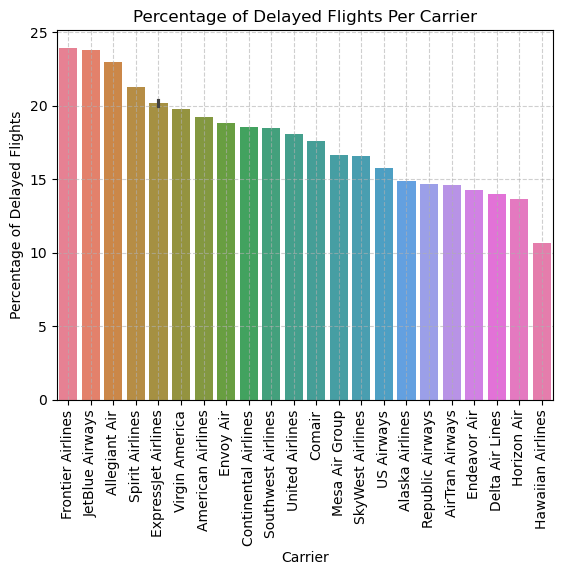

In [32]:
# Calculate the percentage of delayed flights per month
delayed_percentage = bts_ds.groupby('OP_UNIQUE_CARRIER')['IS_DELAYED'].mean() * 100


df = delayed_percentage.reset_index() # reset_index to transpose into desired format for seaborn barplot
df = df.sort_values(by='IS_DELAYED', ascending=False)
df['CARRIER_ABV'] = df['OP_UNIQUE_CARRIER'].map(airline_codes)

# Plot
fig, ax = plt.subplots()
sns.barplot(data=df, x='CARRIER_ABV', y='IS_DELAYED', hue='CARRIER_ABV')


# Display the result
print(delayed_percentage)
plt.grid(True, alpha=0.6, linestyle='--')
plt.ylabel('Percentage of Delayed Flights')
plt.title('Percentage of Delayed Flights Per Carrier')
plt.xlabel('Carrier')

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels


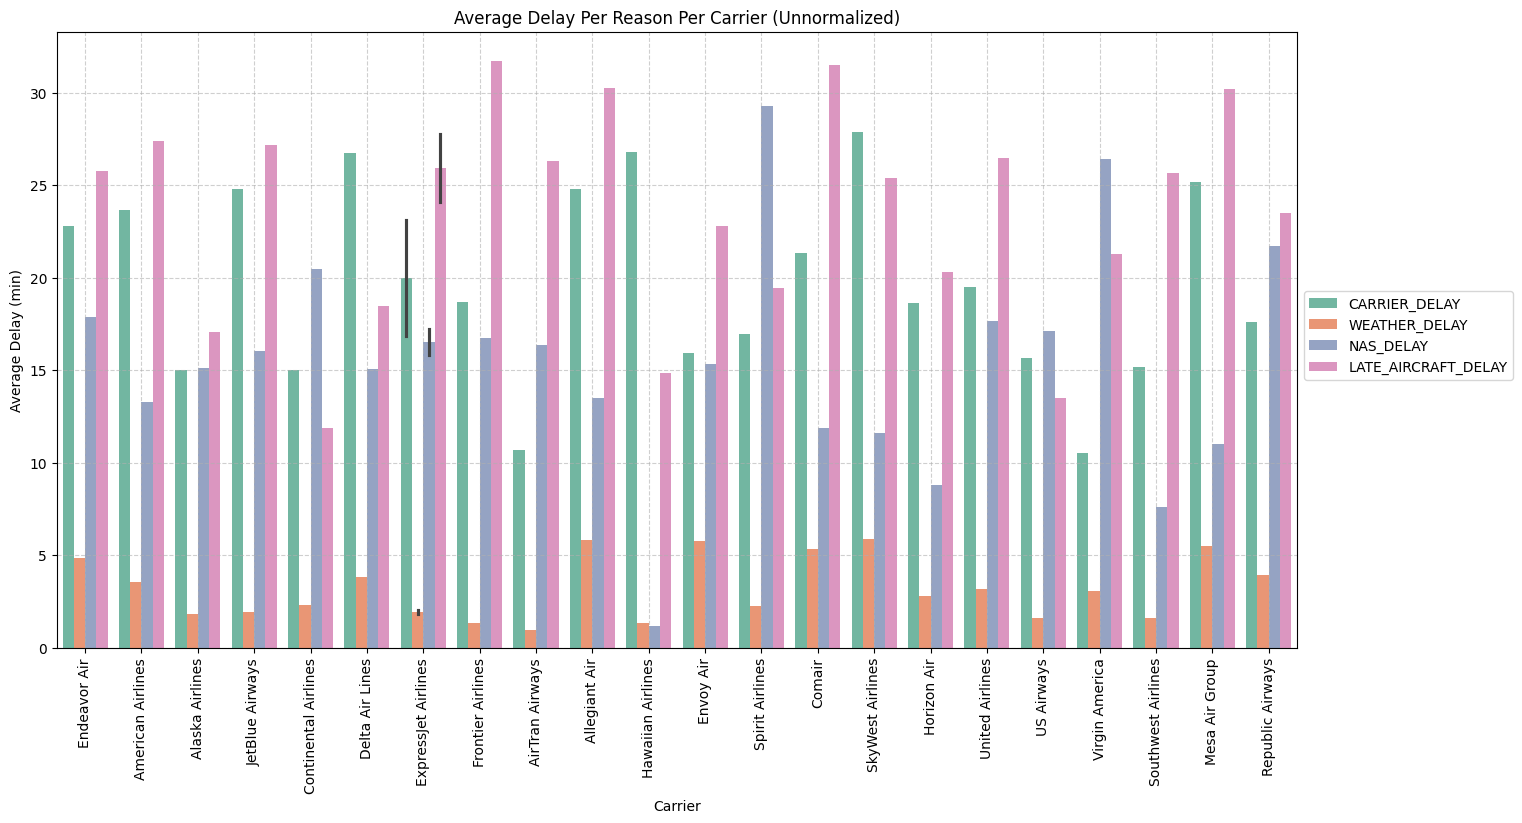

In [25]:
# Unnormalized average delay per carrier
reasons = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'LATE_AIRCRAFT_DELAY']   # 'IS_SECURITY_DELAY' not included because all zeroes

avg_delays = bts_ds.groupby('OP_UNIQUE_CARRIER')[reasons].mean().reset_index()

# create grouped dataframe
df_long = avg_delays.melt(id_vars='OP_UNIQUE_CARRIER', var_name='REASON', value_name='FREQUENCY')
df_long['CARRIER_ABV'] = df_long['OP_UNIQUE_CARRIER'].map(airline_codes)

fig, ax = plt.subplots(figsize=(16,8))
sns.barplot(data=df_long, x='CARRIER_ABV', y='FREQUENCY', hue='REASON', palette='Set2', ax=ax)
ax.legend_.remove() # remove seaborn default legend

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Reason Per Carrier (Unnormalized)')
ax.set_xlabel('Carrier')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels

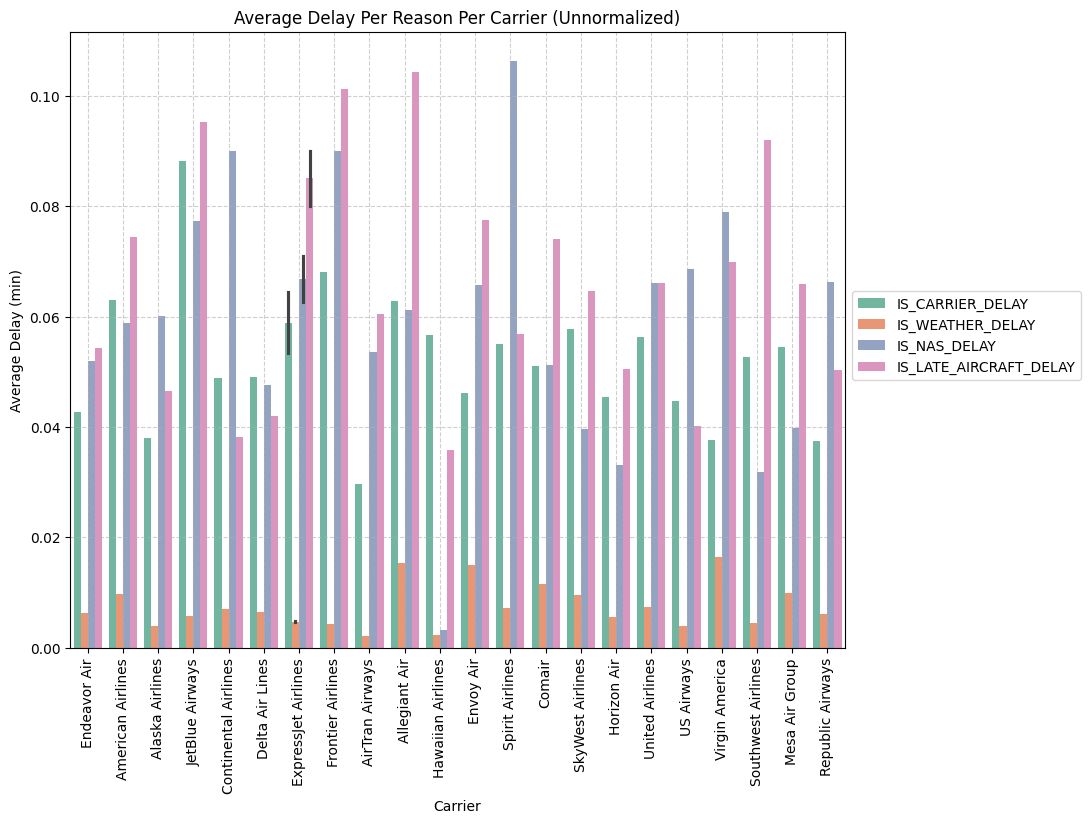

In [19]:
# Unnormalized average likelihood of delay per carrier
reasons = ['IS_CARRIER_DELAY', 'IS_WEATHER_DELAY',	'IS_NAS_DELAY', 'IS_LATE_AIRCRAFT_DELAY']   # 'IS_SECURITY_DELAY' not included because all zeroes

avg_delays = bts_ds.groupby('OP_UNIQUE_CARRIER')[reasons].mean().reset_index()

# create grouped dataframe
df_long = avg_delays.melt(id_vars='OP_UNIQUE_CARRIER', var_name='REASON', value_name='FREQUENCY')
df_long['CARRIER_ABV'] = df_long['OP_UNIQUE_CARRIER'].map(airline_codes)

fig, ax = plt.subplots(figsize=(10,8))
sns.barplot(data=df_long, x='CARRIER_ABV', y='FREQUENCY', hue='REASON', palette='Set2', ax=ax)
ax.legend_.remove() # remove seaborn default legend

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Reason Per Carrier (Unnormalized)')
ax.set_xlabel('Carrier')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels

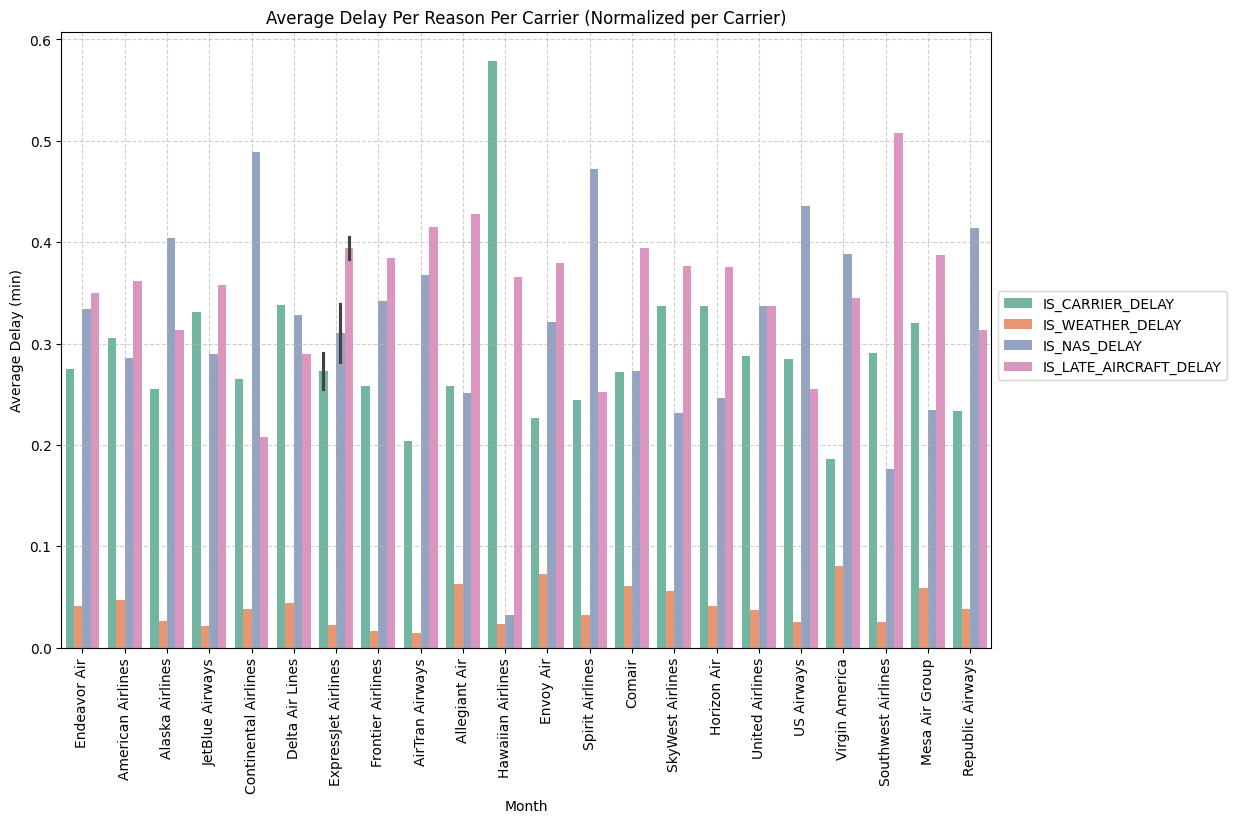

In [ ]:
# Average likelihood of delay per carrier (Normalize all reasons per carrier)
reasons = ['IS_CARRIER_DELAY', 'IS_WEATHER_DELAY',	'IS_NAS_DELAY', 'IS_LATE_AIRCRAFT_DELAY']   # 'IS_SECURITY_DELAY' not included because all zeroes

avg_delays[reasons] = avg_delays[reasons].div(avg_delays[reasons].sum(axis=1), axis=0)

# create grouped dataframe
df_long = avg_delays.melt(id_vars='OP_UNIQUE_CARRIER', var_name='REASON', value_name='FREQUENCY')
df_long['CARRIER_ABV'] = df_long['OP_UNIQUE_CARRIER'].map(airline_codes)

fig, ax = plt.subplots(figsize=(12,8))
sns.barplot(data=df_long, x='CARRIER_ABV', y='FREQUENCY', hue='REASON', palette='Set2', ax=ax)
ax.legend_.remove() # remove seaborn default legend

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Reason Per Carrier (Normalized per Carrier)')
ax.set_xlabel('Month')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels


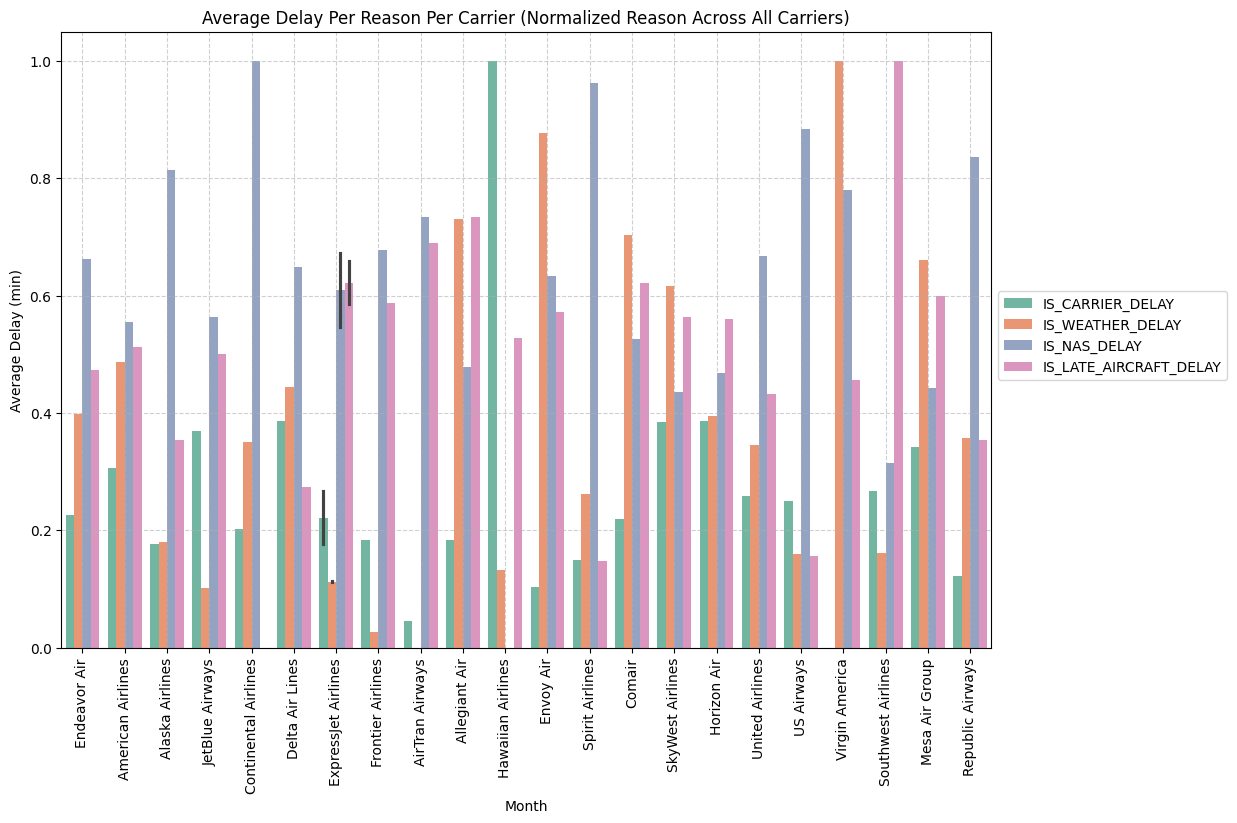

In [21]:
# Average likelihood of delay per carrier (Normalize reason across all carriers)
reasons = ['IS_CARRIER_DELAY', 'IS_WEATHER_DELAY',	'IS_NAS_DELAY', 'IS_LATE_AIRCRAFT_DELAY']   # 'IS_SECURITY_DELAY' not included because all zeroes

avg_delays[reasons] = avg_delays[reasons].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# create grouped dataframe
df_long = avg_delays.melt(id_vars='OP_UNIQUE_CARRIER', var_name='REASON', value_name='FREQUENCY')
df_long['CARRIER_ABV'] = df_long['OP_UNIQUE_CARRIER'].map(airline_codes)

fig, ax = plt.subplots(figsize=(12,8))
sns.barplot(data=df_long, x='CARRIER_ABV', y='FREQUENCY', hue='REASON', palette='Set2', ax=ax)
ax.legend_.remove() # remove seaborn default legend

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Reason Per Carrier (Normalized Reason Across All Carriers)')
ax.set_xlabel('Month')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels


## By Arrival Airport

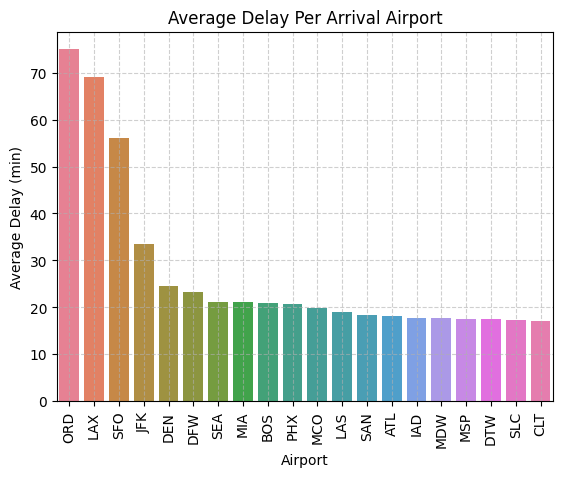

In [ ]:
# Average delay per airport (top 20)

#bts_clean = bts_ds.dropna(subset=['ORIGIN_AIRPORT_ID', 'ARR_DELAY'])
avg_del_airport = bts_ds.groupby('ORIGIN_AIRPORT_ID')['ARR_DELAY'].mean()

df = avg_del_airport.reset_index() # reset_index to transpose into desired format for seaborn barplot
df = df.sort_values(by='ARR_DELAY', ascending=False)
df['AIRPORT_ABV'] = df['ORIGIN_AIRPORT_ID'].map(airport_abbreviations)

# Plot
fig, ax = plt.subplots()
order = df['AIRPORT_ABV'].iloc[0:20].tolist()
sns.barplot(data=df[0:20], x='AIRPORT_ABV', y='ARR_DELAY', order=order, hue='AIRPORT_ABV')

# Check to form dictionaries:
#order = df['ORIGIN_AIRPORT_ID'].iloc[0:20].tolist()
#sns.barplot(data=df[0:20], x='ORIGIN_AIRPORT_ID', y='ARR_DELAY', order=order, hue='ORIGIN_AIRPORT_ID')
#ax.legend_.remove() # remove seaborn default legend

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Arrival Airport')
ax.set_xlabel('Airport')

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels

In [70]:
print(order)

['ORD', 'LAX', 'SFO', 'JFK', 'DEN', 'DFW', 'SEA', 'MIA', 'BOS', 'PHX', 'MCO', 'LAS', 'SAN', 'ATL', 'IAD', 'MDW', 'MSP', 'DTW', 'SLC', 'CLT']


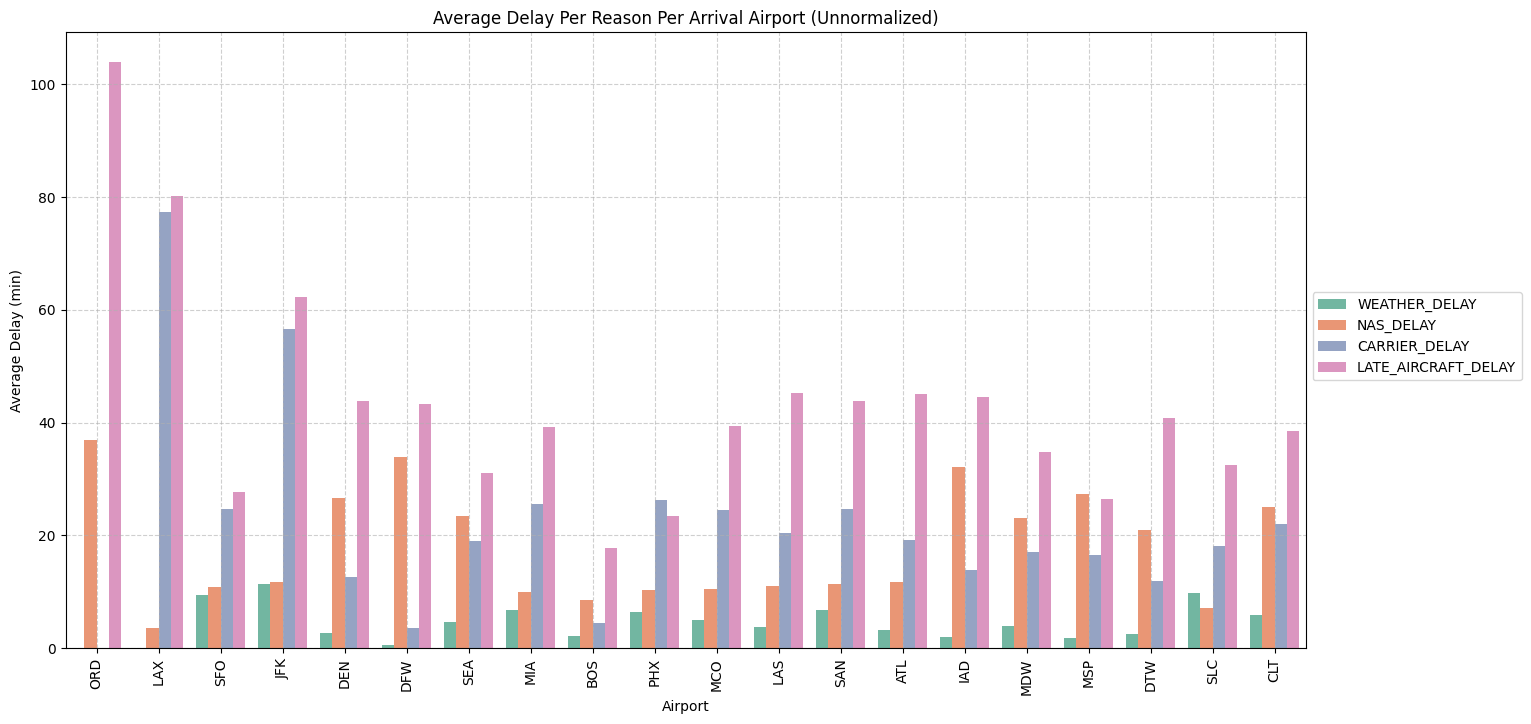

In [81]:
# Unnormalized average delay per carrier
reasons = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'LATE_AIRCRAFT_DELAY']   # 'IS_SECURITY_DELAY' not included because all zeroes
selected_airports = list(map(airport_abv_to_code.get, order))

filtered_data = bts_ds[bts_ds['ORIGIN_AIRPORT_ID'].isin(selected_airports)]
avg_delays = filtered_data.groupby('ORIGIN_AIRPORT_ID')[reasons].mean().reset_index()

# create grouped dataframe
df_long = avg_delays.melt(id_vars='ORIGIN_AIRPORT_ID', var_name='REASON', value_name='FREQUENCY')
df_long['AIRPORT_ABV'] = df_long['ORIGIN_AIRPORT_ID'].map(airport_abbreviations)


# Ensure AIRPORT_ABV has a defined categorical order
df_long['AIRPORT_ABV'] = pd.Categorical(
    df_long['AIRPORT_ABV'],
    categories=order,  # original list of abbreviations
    ordered=True
)

# Now sort the dataframe based on that order
df_long = df_long.sort_values('AIRPORT_ABV')


fig, ax = plt.subplots(figsize=(16,8))
#order = df['AIRPORT_ABV'].iloc[0:20].tolist()
sns.barplot(data=df_long, x='AIRPORT_ABV', y='FREQUENCY', hue='REASON', palette='Set2', ax=ax)
ax.legend_.remove() # remove seaborn default legend

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Reason Per Arrival Airport (Unnormalized)')
ax.set_xlabel('Airport')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels

In [75]:
selected_airports

[16133,
 13282,
 14082,
 14222,
 13964,
 10930,
 12265,
 12119,
 10917,
 14761,
 12223,
 12917,
 10676,
 12544,
 12250,
 13388,
 12320,
 15497,
 13983,
 13541]

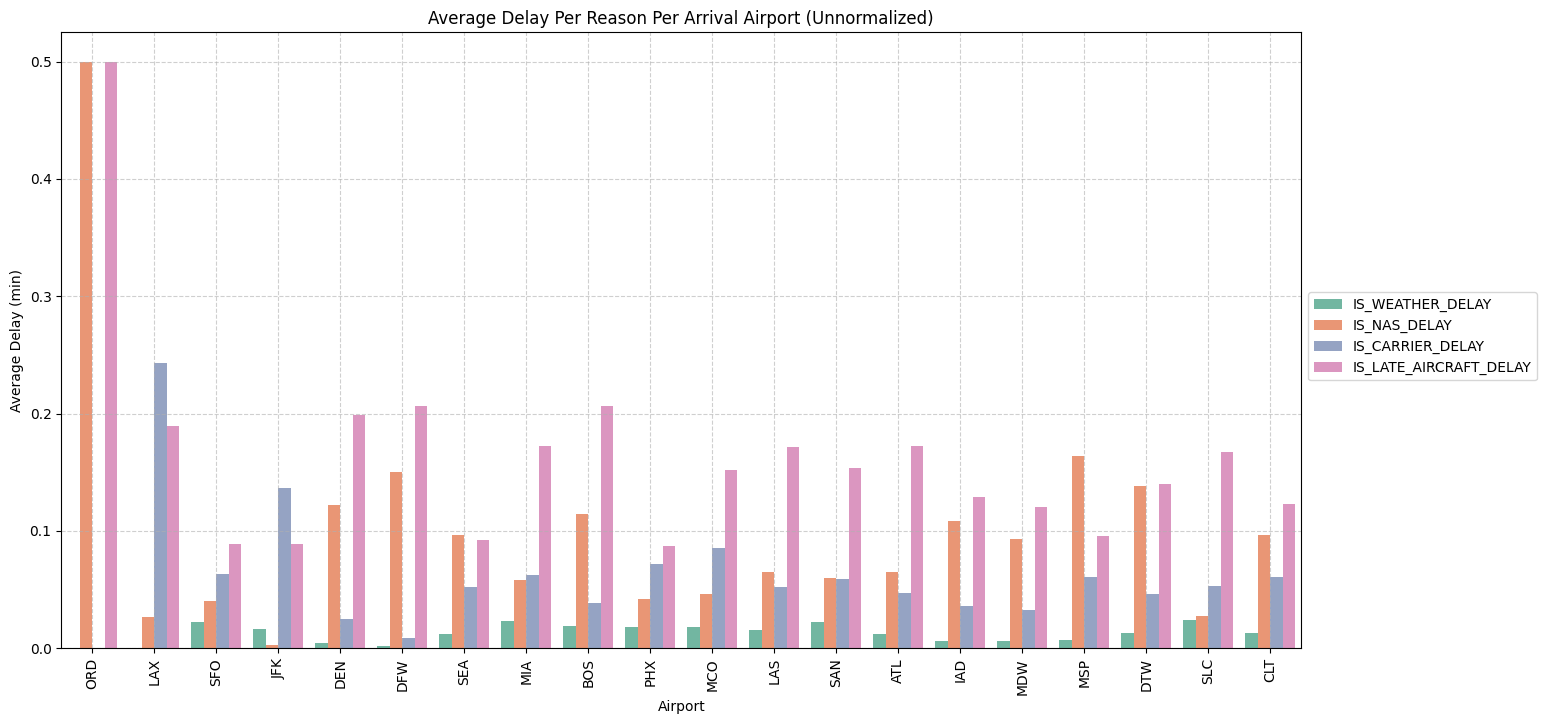

In [ ]:
# Unnormalized likelihood of average delay per carrier
reasons = ['IS_CARRIER_DELAY', 'IS_WEATHER_DELAY', 'IS_NAS_DELAY', 'IS_LATE_AIRCRAFT_DELAY']   # 'IS_SECURITY_DELAY' not included because all zeroes
selected_airports = list(map(airport_abv_to_code.get, order))

filtered_data = bts_ds[bts_ds['ORIGIN_AIRPORT_ID'].isin(selected_airports)]
avg_delays = filtered_data.groupby('ORIGIN_AIRPORT_ID')[reasons].mean().reset_index()

# create grouped dataframe
df_long = avg_delays.melt(id_vars='ORIGIN_AIRPORT_ID', var_name='REASON', value_name='FREQUENCY')
df_long['AIRPORT_ABV'] = df_long['ORIGIN_AIRPORT_ID'].map(airport_abbreviations)


# Ensure AIRPORT_ABV has a defined categorical order
df_long['AIRPORT_ABV'] = pd.Categorical(
    df_long['AIRPORT_ABV'],
    categories=order,  # original list of abbreviations
    ordered=True
)

# Now sort the dataframe based on that order
df_long = df_long.sort_values('AIRPORT_ABV')


fig, ax = plt.subplots(figsize=(16,8))
sns.barplot(data=df_long, x='AIRPORT_ABV', y='FREQUENCY', hue='REASON', palette='Set2', ax=ax)
ax.legend_.remove() # remove seaborn default legend

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Reason Per Arrival Airport (Unnormalized)')
ax.set_xlabel('Airport')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels

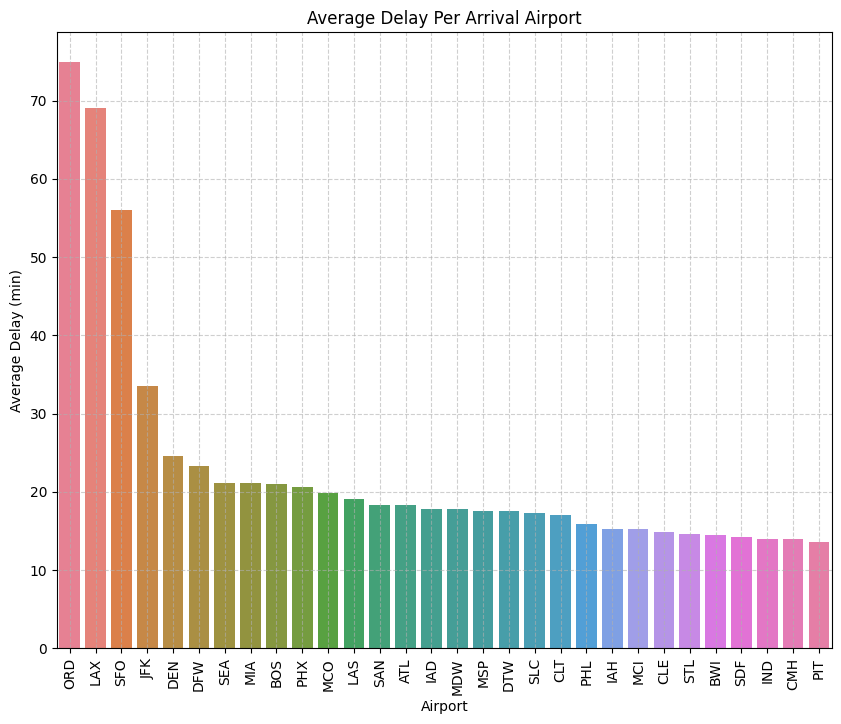

In [63]:
# Average delay per airport (top 30)

avg_del_airport = bts_ds.groupby('ORIGIN_AIRPORT_ID')['ARR_DELAY'].mean()

df = avg_del_airport.reset_index() # reset_index to transpose into desired format for seaborn barplot
df = df.sort_values(by='ARR_DELAY', ascending=False)
df['AIRPORT_ABV'] = df['ORIGIN_AIRPORT_ID'].map(airport_abbreviations)

# Plot
fig, ax = plt.subplots(figsize=(10,8))
order = df['AIRPORT_ABV'].iloc[0:30].tolist()
sns.barplot(data=df[0:30], x='AIRPORT_ABV', y='ARR_DELAY', order=order, hue='AIRPORT_ABV')
#ax.legend_.remove() # remove seaborn default legend

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Arrival Airport')
ax.set_xlabel('Airport')

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels

## By Destination Airport

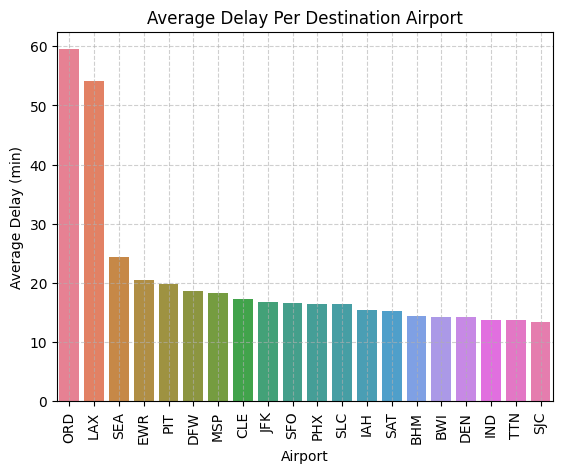

In [ ]:
# Average delay per airport (top 20)

bts_clean = bts_ds.dropna(subset=['DEST_AIRPORT_ID', 'ARR_DELAY'])
avg_del_airport = bts_clean.groupby('DEST_AIRPORT_ID')['ARR_DELAY'].mean()

df = avg_del_airport.reset_index() # reset_index to transpose into desired format for seaborn barplot
df = df.sort_values(by='ARR_DELAY', ascending=False)
df['AIRPORT_ABV'] = df['DEST_AIRPORT_ID'].map(airport_abbreviations)

# Plot
fig, ax = plt.subplots()
order = df['AIRPORT_ABV'].iloc[0:20].tolist()
sns.barplot(data=df[0:20], x='AIRPORT_ABV', y='ARR_DELAY', order=order, hue='AIRPORT_ABV')

# Check to form dictionaries:
#order = df['DEST_AIRPORT_ID'].iloc[0:40].tolist()
#sns.barplot(data=df[0:20], x='DEST_AIRPORT_ID', y='ARR_DELAY', order=order, hue='DEST_AIRPORT_ID')
#ax.legend_.remove() # remove seaborn default legend

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Destination Airport')
ax.set_xlabel('Airport')

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels

In [52]:
print(order)

[16133, 13282, 11726, 12365, 14314, 10930, 12320, 13424, 14222, 14082, 14761, 10617, 11002, 15454, 10732, 10372, 13964, 14254, 15356, 14092, 13832, 10466, 14112, 10157, 12917, 12559, 13459, 14802, 10917, 12544, 11027, 11618, 13241, 15070, 14487, 11076, 15497, 12197, 14025, 11503]


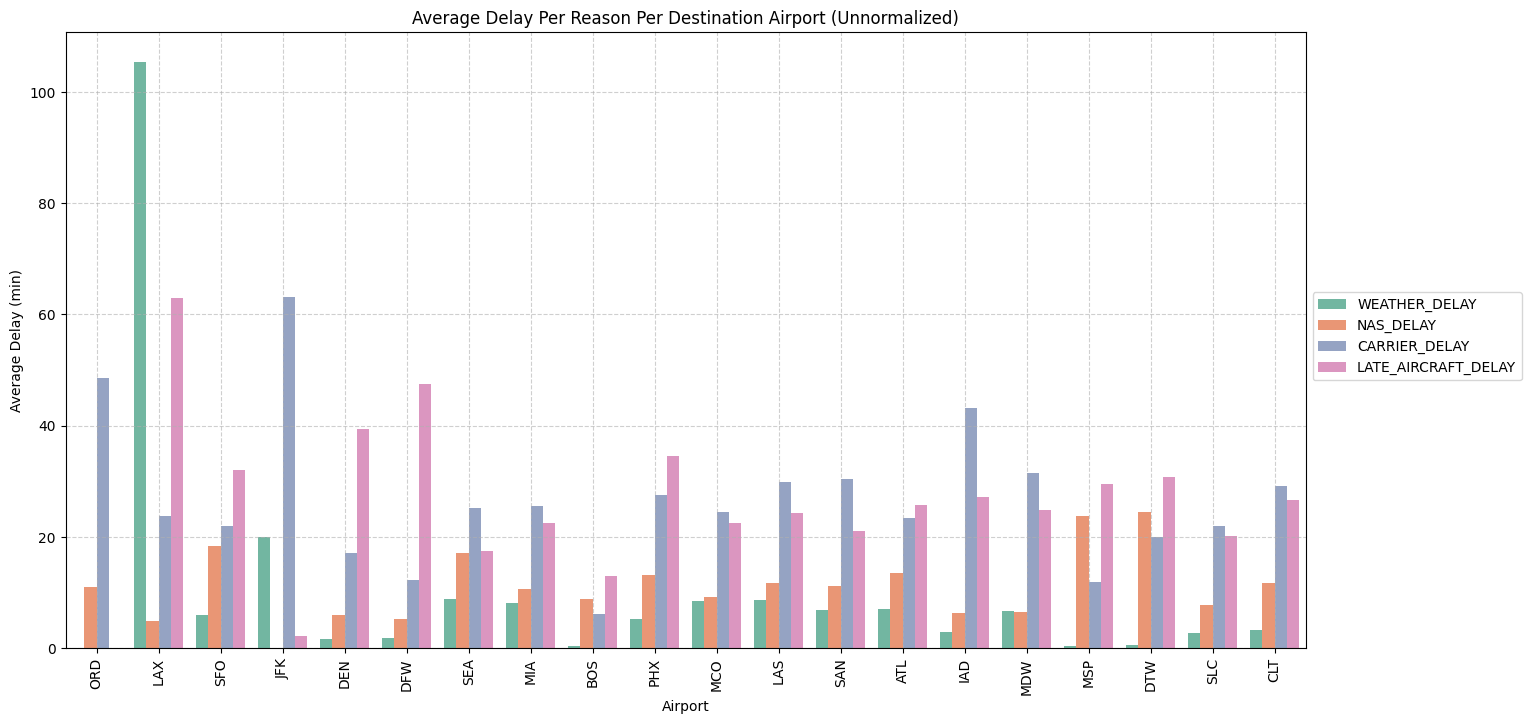

In [ ]:
# Unnormalized average delay per carrier
reasons = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'LATE_AIRCRAFT_DELAY']   # 'IS_SECURITY_DELAY' not included because all zeroes
selected_airports = list(map(airport_abv_to_code.get, order))

filtered_data = bts_ds[bts_ds['DEST_AIRPORT_ID'].isin(selected_airports)]
avg_delays = filtered_data.groupby('DEST_AIRPORT_ID')[reasons].mean().reset_index()

# create grouped dataframe
df_long = avg_delays.melt(id_vars='DEST_AIRPORT_ID', var_name='REASON', value_name='FREQUENCY')
df_long['AIRPORT_ABV'] = df_long['DEST_AIRPORT_ID'].map(airport_abbreviations)


# Ensure AIRPORT_ABV has a defined categorical order
df_long['AIRPORT_ABV'] = pd.Categorical(
    df_long['AIRPORT_ABV'],
    categories=order,  # original list of abbreviations
    ordered=True
)

# Now sort the dataframe based on that order
df_long = df_long.sort_values('AIRPORT_ABV')

fig, ax = plt.subplots(figsize=(16,8))
sns.barplot(data=df_long, x='AIRPORT_ABV', y='FREQUENCY', hue='REASON', palette='Set2', ax=ax)
ax.legend_.remove() # remove seaborn default legend

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Reason Per Destination Airport (Unnormalized)')
ax.set_xlabel('Airport')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels

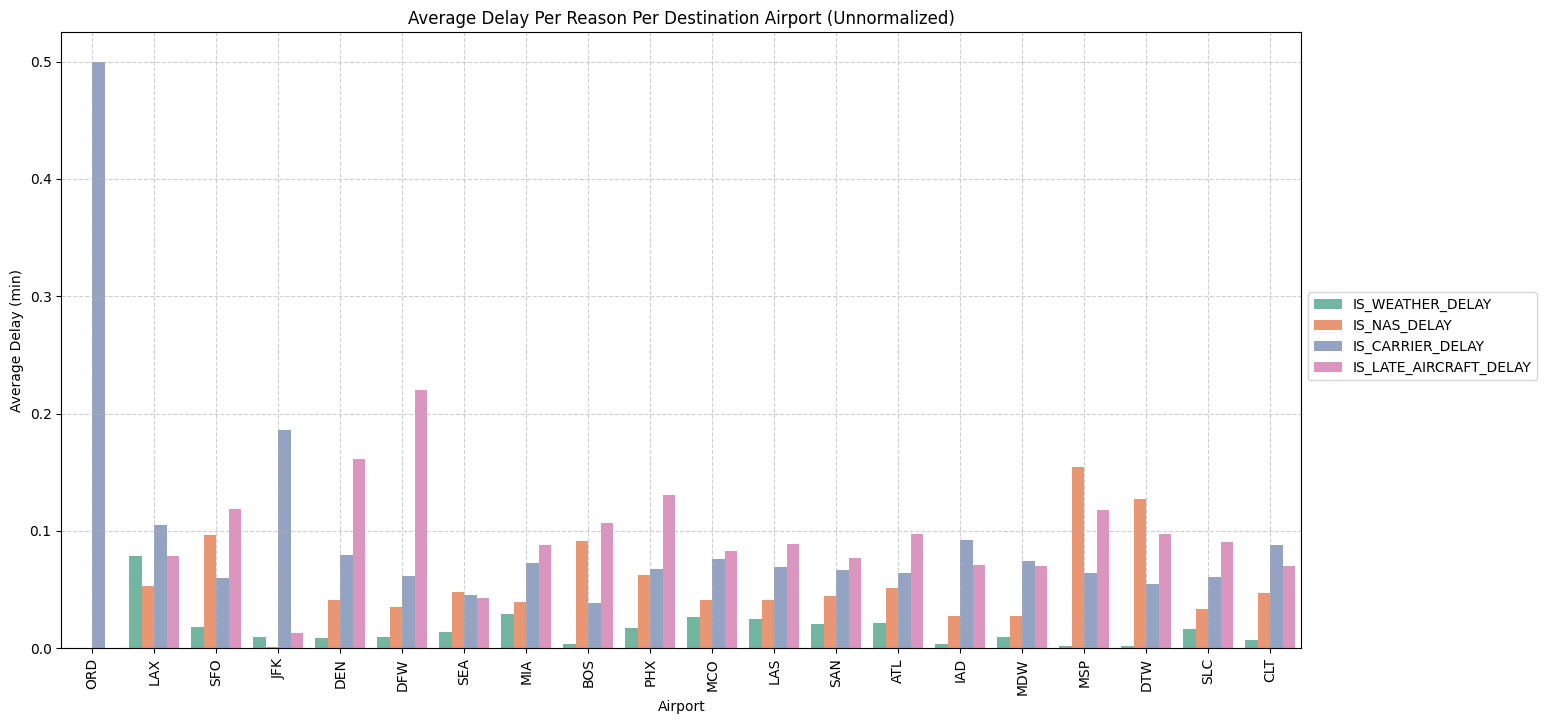

In [ ]:
# Unnormalized likelihood of average delay per carrier
reasons = ['IS_CARRIER_DELAY', 'IS_WEATHER_DELAY', 'IS_NAS_DELAY', 'IS_LATE_AIRCRAFT_DELAY']   # 'IS_SECURITY_DELAY' not included because all zeroes
selected_airports = list(map(airport_abv_to_code.get, order))

filtered_data = bts_ds[bts_ds['DEST_AIRPORT_ID'].isin(selected_airports)]
avg_delays = filtered_data.groupby('DEST_AIRPORT_ID')[reasons].mean().reset_index()

# create grouped dataframe
df_long = avg_delays.melt(id_vars='DEST_AIRPORT_ID', var_name='REASON', value_name='FREQUENCY')
df_long['AIRPORT_ABV'] = df_long['DEST_AIRPORT_ID'].map(airport_abbreviations)

# Ensure AIRPORT_ABV has a defined categorical order
df_long['AIRPORT_ABV'] = pd.Categorical(
    df_long['AIRPORT_ABV'],
    categories=order,  # original list of abbreviations
    ordered=True
)

# Now sort the dataframe based on that order
df_long = df_long.sort_values('AIRPORT_ABV')


fig, ax = plt.subplots(figsize=(16,8))
sns.barplot(data=df_long, x='AIRPORT_ABV', y='FREQUENCY', hue='REASON', palette='Set2', ax=ax)
ax.legend_.remove() # remove seaborn default legend

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Reason Per Destination Airport (Unnormalized)')
ax.set_xlabel('Airport')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels

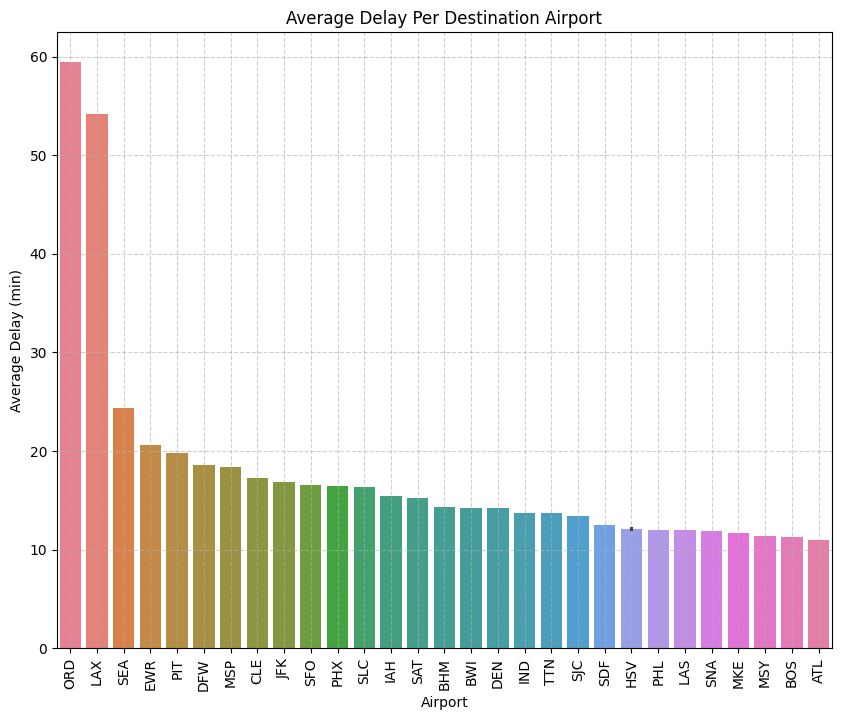

In [59]:
# Average delay per airport (top 30)

bts_clean = bts_ds.dropna(subset=['DEST_AIRPORT_ID', 'ARR_DELAY'])
avg_del_airport = bts_ds.groupby('DEST_AIRPORT_ID')['ARR_DELAY'].mean()

df = avg_del_airport.reset_index() # reset_index to transpose into desired format for seaborn barplot
df = df.sort_values(by='ARR_DELAY', ascending=False)
df['AIRPORT_ABV'] = df['DEST_AIRPORT_ID'].map(airport_abbreviations)

# Plot
fig, ax = plt.subplots(figsize=(10,8))
order = df['AIRPORT_ABV'].iloc[0:30].tolist()
sns.barplot(data=df[0:30], x='AIRPORT_ABV', y='ARR_DELAY', order=order, hue='AIRPORT_ABV')
#ax.legend_.remove() # remove seaborn default legend

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Average Delay Per Destination Airport')
ax.set_xlabel('Airport')

plt.setp(ax.get_xticklabels(), rotation=90); # rotate x labels

## Models

### Linear Regression

regression m: [0.02450693]
regression b: -44.97215690843571
regression score: 0.001354548348581397


Text(0.5, 0, 'Year')

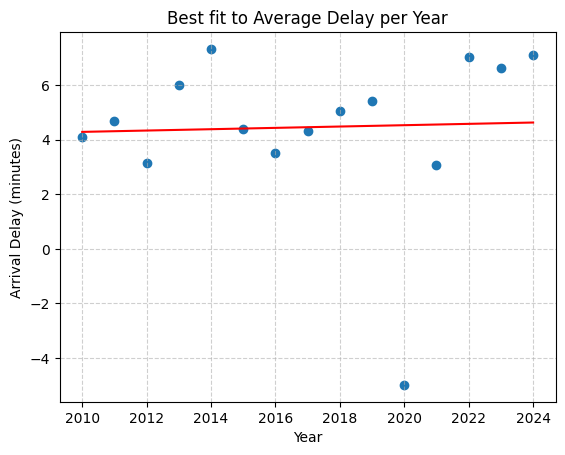

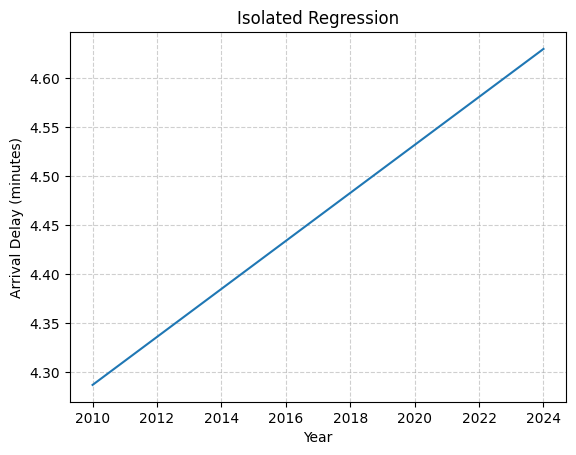

In [5]:
# Linear Regression Per Year
avg_del_year = bts_ds.groupby('YEAR')['ARR_DELAY'].mean()

x = avg_del_year.index.to_numpy().reshape(-1, 1) # convert into 2D for linear regression
y = avg_del_year.values

reg_by_year = lm.LinearRegression().fit(x, y)
print("regression m:", reg_by_year.coef_)
print("regression b:",reg_by_year.intercept_)
print("regression score:",reg_by_year.score(x, y))


# plot together
fig, ax = plt.subplots()

ax.scatter(x, y, label='Actual')

years = np.arange(2010,2025).reshape(-1, 1)
y_pred = reg_by_year.predict(years)
ax.plot(years, y_pred, color='red', label='Predicted')

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Arrival Delay (minutes)')
ax.set_title('Best fit to Average Delay per Year')
ax.set_xlabel('Year')


# plot regression by itself
fig, ax = plt.subplots()
ax.plot(years, y_pred)

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Arrival Delay (minutes)')
ax.set_title('Isolated Regression')
ax.set_xlabel('Year')

regression m: [-0.1060534]
regression b: 5.335055908450386
regression score: 0.016291001682637196


Text(0.5, 0, 'Month')

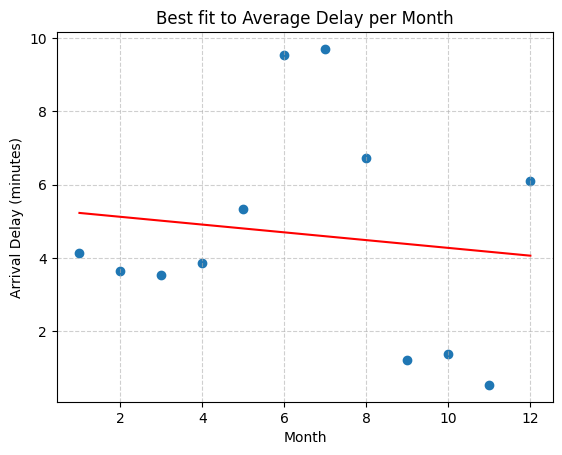

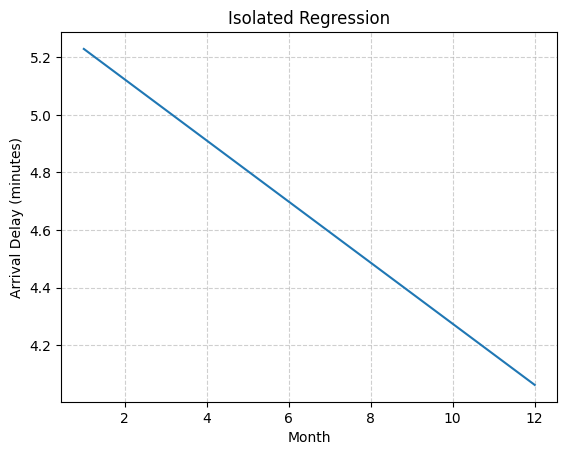

In [6]:
# Linear Regression Per Month
avg_del_month = bts_ds.groupby('MONTH')['ARR_DELAY'].mean()

x = avg_del_month.index.to_numpy().reshape(-1, 1) # convert into 2D for linear regression
y = avg_del_month.values

reg_by_month = lm.LinearRegression().fit(x, y)
print("regression m:", reg_by_month.coef_)
print("regression b:",reg_by_month.intercept_)
print("regression score:",reg_by_month.score(x, y))


# plot together
fig, ax = plt.subplots()

ax.scatter(x, y, label='Actual')

months = np.arange(1,13).reshape(-1, 1)
y_pred = reg_by_month.predict(months)
ax.plot(months, y_pred, color='red', label='Predicted')

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Arrival Delay (minutes)')
ax.set_title('Best fit to Average Delay per Month')
ax.set_xlabel('Month')


# plot regression by itself
fig, ax = plt.subplots()
ax.plot(months, y_pred)

ax.grid(True, alpha=0.6, linestyle='--')
ax.set_ylabel('Arrival Delay (minutes)')
ax.set_title('Isolated Regression')
ax.set_xlabel('Month')

In [89]:
x.shape

(180, 2)

regression m: [ 0.00308531 -0.09811664]
regression b: -1.2910243784998299
regression score: 0.00459110292833631


/var/folders/7b/p48y5r2x3651sg0l3xk49lqwxfrj3r/T/ipykernel_92640/3581544835.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


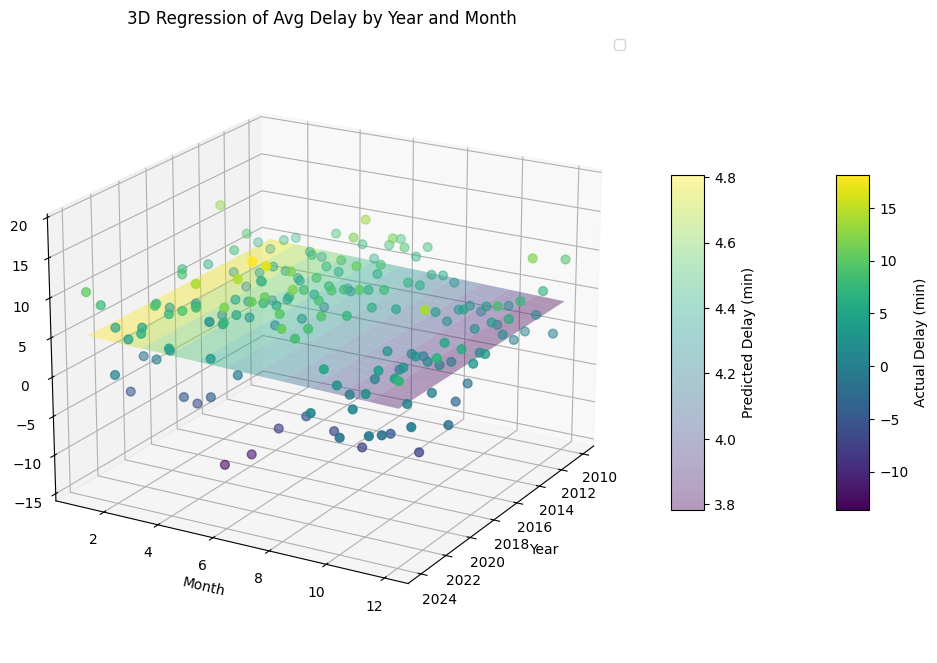

In [96]:
# Linear Regression Per Year and Month
from mpl_toolkits.mplot3d import Axes3D

avg_del_year = bts_ds.groupby(['YEAR', 'MONTH'])['ARR_DELAY'].mean()

x = np.array(avg_del_year.index.tolist())
y = avg_del_year.values

reg_by_year = lm.LinearRegression().fit(x, y)
print("regression m:", reg_by_year.coef_)
print("regression b:",reg_by_year.intercept_)
print("regression score:",reg_by_year.score(x, y))


# 3D Plot

# Prepare your 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of actual data
year = x[:, 0]
month = x[:, 1]
# 3D scatter where color represents actual delay (y)
scatter = ax.scatter(year, month, y, c=y, cmap='viridis', s=40)
# Add colorbar to explain color meaning
fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, label='Actual Delay (min)')


# Create a meshgrid for YEAR and MONTH to compute predicted values
year_range = np.linspace(year.min(), year.max(), 20)
month_range = np.linspace(month.min(), month.max(), 12)
year_grid, month_grid = np.meshgrid(year_range, month_range)
x_pred = np.column_stack((year_grid.ravel(), month_grid.ravel()))
y_pred = reg_by_year.predict(x_pred).reshape(year_grid.shape)

# Plot regression surface
surf = ax.plot_surface(year_grid, month_grid, y_pred, alpha=0.4, cmap='viridis')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Predicted Delay (min)')

# Labels
ax.set_xlabel('Year')
ax.set_ylabel('Month')
ax.set_zlabel('Avg Arrival Delay')
ax.set_title('3D Regression of Avg Delay by Year and Month')
ax.legend()

ax.view_init(elev=20, azim=30)

plt.tight_layout()
plt.show()

### Data Splitting for Classification Algorithms

In [3]:
# Split Data by Everything Else vs. Is_Delayed

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline

#bts_clean = bts_ds.dropna(subset=['IS_DELAYED', 'MONTH'])

# Select feature columns
feature_cols = ['YEAR', 'MONTH', 'OP_UNIQUE_CARRIER', 'ORIGIN_AIRPORT_ID',
                'ORIGIN_STATE_ABR', 'DEST_AIRPORT_ID', 'DEST_STATE_ABR']

x = bts_ds[feature_cols]
y = bts_ds['IS_DELAYED'].astype(int)

# Identify categorical and numeric columns
categorical = ['OP_UNIQUE_CARRIER', 'ORIGIN_AIRPORT_ID', 'ORIGIN_STATE_ABR', 'DEST_AIRPORT_ID', 'DEST_STATE_ABR']
numeric = ['YEAR', 'MONTH']

# Column transformer to preprocess
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numeric)
])

# Train-test split
Xtrain, Xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=4)

In [3]:
# Only include numerical data

# Select feature columns
feature_cols = ['YEAR', 'MONTH']

x = bts_ds[feature_cols]
y = bts_ds['IS_DELAYED'].astype(int)

# Train-test split
Xtrain, Xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=4)

In [ ]:
# Split Data by Month vs. Is_Delayed

bts_clean = bts_ds.dropna(subset=['IS_DELAYED', 'MONTH'])

x = bts_clean[['MONTH']].to_numpy().reshape(-1, 1)
y = bts_clean['IS_DELAYED']

Xtrain, Xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=4)

Xtrain = Xtrain.astype(int)
Xtest = Xtest.astype(int)
ytrain = ytrain.astype(int)
ytest = ytest.astype(int)

print("Sizes")
print("Xtrain size:", Xtrain.size)
print("Xtest size:", Xtest.size)

### Logistic Regression

In [5]:
# Printing LogReg Auxiliary Functions

'''
print_cm visualizes the given confusion matrix cm.
> Referenced source: precept 7
'''
def print_cm(cm):
  plt.figure(figsize=(4,2))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Delayed', 'Delayed'], yticklabels=['Not Delayed', 'Delayed'])
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.title('Confusion Matrix')
  plt.show()


'''
print_train_sc prints the four measure of "goodness" scores by comparing actual
and predicted target classifications.
> Referenced source: precept 7
'''
def print_train_sc(actual, predicted):
  accuracy = accuracy_score(actual, predicted)
  print(f"Accuracy: {accuracy}")

  precision = precision_score(actual, predicted, average='macro')
  print("Precision:", precision)

  recall = recall_score(actual, predicted, average='macro')
  print("Recall:", recall)

  f1 = f1_score(actual, predicted, average='macro')
  print("F1 Score:", f1)


'''
print_results prints the results of training and testing "goodness" scores and
the confusion matrix outputted from a pipeline using a particular binary
classification model.
'''
def print_results(pipe, Xtrain, Xtest, ytrain, ytest):
  # TRAINING
  print("-----------------TRAINING-----------------")
  print("Training Score:", pipe.fit(Xtrain, np.ravel(ytrain)).score(Xtrain, ytrain))
  ytrain_pred = pipe.predict(Xtrain)
  print_train_sc(ytrain, ytrain_pred)

  # Confusion Matrix
  # > Referenced source:
    # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix
  print("")
  cm = sklearn.metrics.confusion_matrix(ytrain, ytrain_pred)
  print_cm(cm)

  # TESTING
  print("")
  print("-----------------TESTING-----------------")
  print("Testing Score:", pipe.fit(Xtrain, np.ravel(ytrain)).score(Xtest, ytest))
  ytest_pred = pipe.predict(Xtest)
  print_train_sc(ytest, ytest_pred)

  print("")
  cm = sklearn.metrics.confusion_matrix(ytest, ytest_pred)
  print_cm(cm)

-----------------TRAINING-----------------
Training Score: 0.8017841705015745
Training Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89   3973131
           1       0.00      0.00      0.00    982225

    accuracy                           0.80   4955356
   macro avg       0.40      0.50      0.44   4955356
weighted avg       0.64      0.80      0.71   4955356



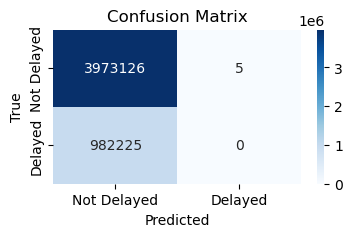

-----------------TESTING-----------------
Testing Score: 0.8016866590542561
Training Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89   1702562
           1       0.50      0.00      0.00    421163

    accuracy                           0.80   2123725
   macro avg       0.65      0.50      0.44   2123725
weighted avg       0.74      0.80      0.71   2123725



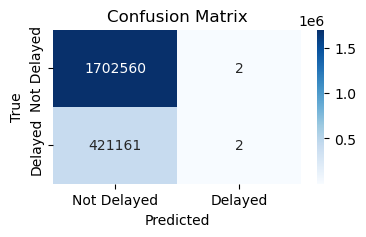

In [ ]:
# Logistic regression model

pipeLR = make_pipeline(preprocessor, lm.LogisticRegression(max_iter=1000))
pipeLR.fit(Xtrain, ytrain).score(Xtrain, ytrain)
ytrain_pred = pipeLR.predict(Xtrain)
ytest_pred = pipeLR.predict(Xtest)

print("-----------------TRAINING-----------------")
print("Training Score:", pipeLR.score(Xtrain, ytrain))
print("Training Classification Report:\n", classification_report(ytrain, ytrain_pred))
cm = confusion_matrix(ytrain, ytrain_pred)
print_cm(cm)


print("-----------------TESTING-----------------")
print("Testing Score:", pipeLR.score(Xtest, ytest))
print("Training Classification Report:\n", classification_report(ytest, ytest_pred))
cm = confusion_matrix(ytest, ytest_pred)
print_cm(cm)


-----------------TRAINING-----------------
Training Score: 0.5624163026833995
Training Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.56      0.67   3973131
           1       0.24      0.56      0.34    982225

    accuracy                           0.56   4955356
   macro avg       0.54      0.56      0.51   4955356
weighted avg       0.72      0.56      0.61   4955356



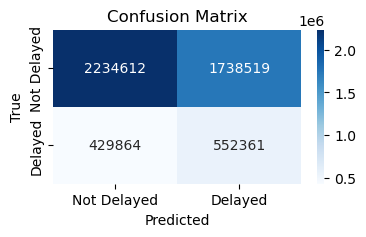

-----------------TESTING-----------------
Testing Score: 0.5626057987733817
Training Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.56      0.67   1702562
           1       0.24      0.56      0.34    421163

    accuracy                           0.56   2123725
   macro avg       0.54      0.56      0.51   2123725
weighted avg       0.72      0.56      0.61   2123725



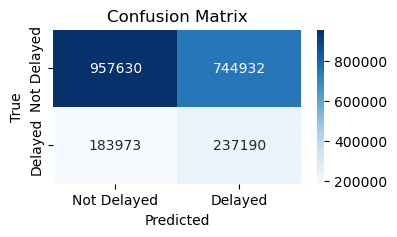

In [ ]:
# Logistic regression model - Balanced classes

pipeLR = make_pipeline(preprocessor, lm.LogisticRegression(class_weight='balanced', max_iter=1000))
pipeLR.fit(Xtrain, ytrain).score(Xtrain, ytrain)
ytrain_pred = pipeLR.predict(Xtrain)
ytest_pred = pipeLR.predict(Xtest)

print("-----------------TRAINING-----------------")
print("Training Score:", pipeLR.score(Xtrain, ytrain))
print("Training Classification Report:\n", classification_report(ytrain, ytrain_pred))
cm = confusion_matrix(ytrain, ytrain_pred)
print_cm(cm)


print("-----------------TESTING-----------------")
print("Testing Score:", pipeLR.score(Xtest, ytest))
print("Training Classification Report:\n", classification_report(ytest, ytest_pred))
cm = confusion_matrix(ytest, ytest_pred)
print_cm(cm)


Area Under Curve: 0.5882978243527012


Text(0.5, 1.0, 'Logistic Regression ROC Curve')

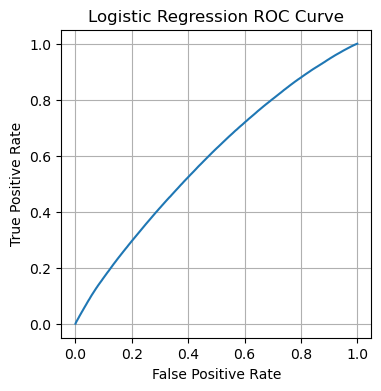

In [14]:
# ROC for Logistic Regression
# Referenced sources:
  # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html
  # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html
  # https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.predict_proba

ytest_probs = pipeLR.predict_proba(Xtest)
fpr, tpr, thresholds = roc_curve(ytest, ytest_probs[:,1])
print("Area Under Curve:", auc(fpr, tpr))

fig, ax = plt.subplots(figsize=(4,4))
ax.plot(fpr, tpr)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.grid()
ax.set_title('Logistic Regression ROC Curve')

### Naive Bayes

In [15]:
from sklearn.naive_bayes import GaussianNB

# Referenced source: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html#sklearn.naive_bayes.GaussianNB AND precept 7

print("NAIVE BAYES (GAUSSIAN)")
pipeNB = make_pipeline(StandardScaler(), GaussianNB())

print_results(pipeNB, Xtrain, Xtest, ytrain, ytest)

NAIVE BAYES (GAUSSIAN)
-----------------TRAINING-----------------


ValueError: could not convert string to float: '9E'

### Decision Tree

DECISION TREE
-----------------TRAINING-----------------
Training Score: 0.8042033710595162
Accuracy: 0.8042033710595162
Precision: 0.7013283078391908
Recall: 0.5157884476260102
F1 Score: 0.48095156663456



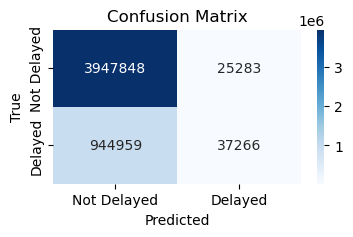


-----------------TESTING-----------------
Testing Score: 0.8008193151184828
Accuracy: 0.8008193151184828
Precision: 0.6359074078292102
Recall: 0.510954998401403
F1 Score: 0.4729941729953936



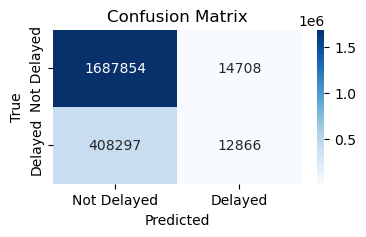

In [ ]:
# Referenced source: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
from sklearn.tree import DecisionTreeClassifier

print("DECISION TREE")

# Create a pipeline with encoding and classifier
pipeDT = Pipeline([
    ('transformer', preprocessor),
    ('classifier', DecisionTreeClassifier())
])

print_results(pipeDT, Xtrain, Xtest, ytrain, ytest)

<Figure size 2000x1000 with 0 Axes>

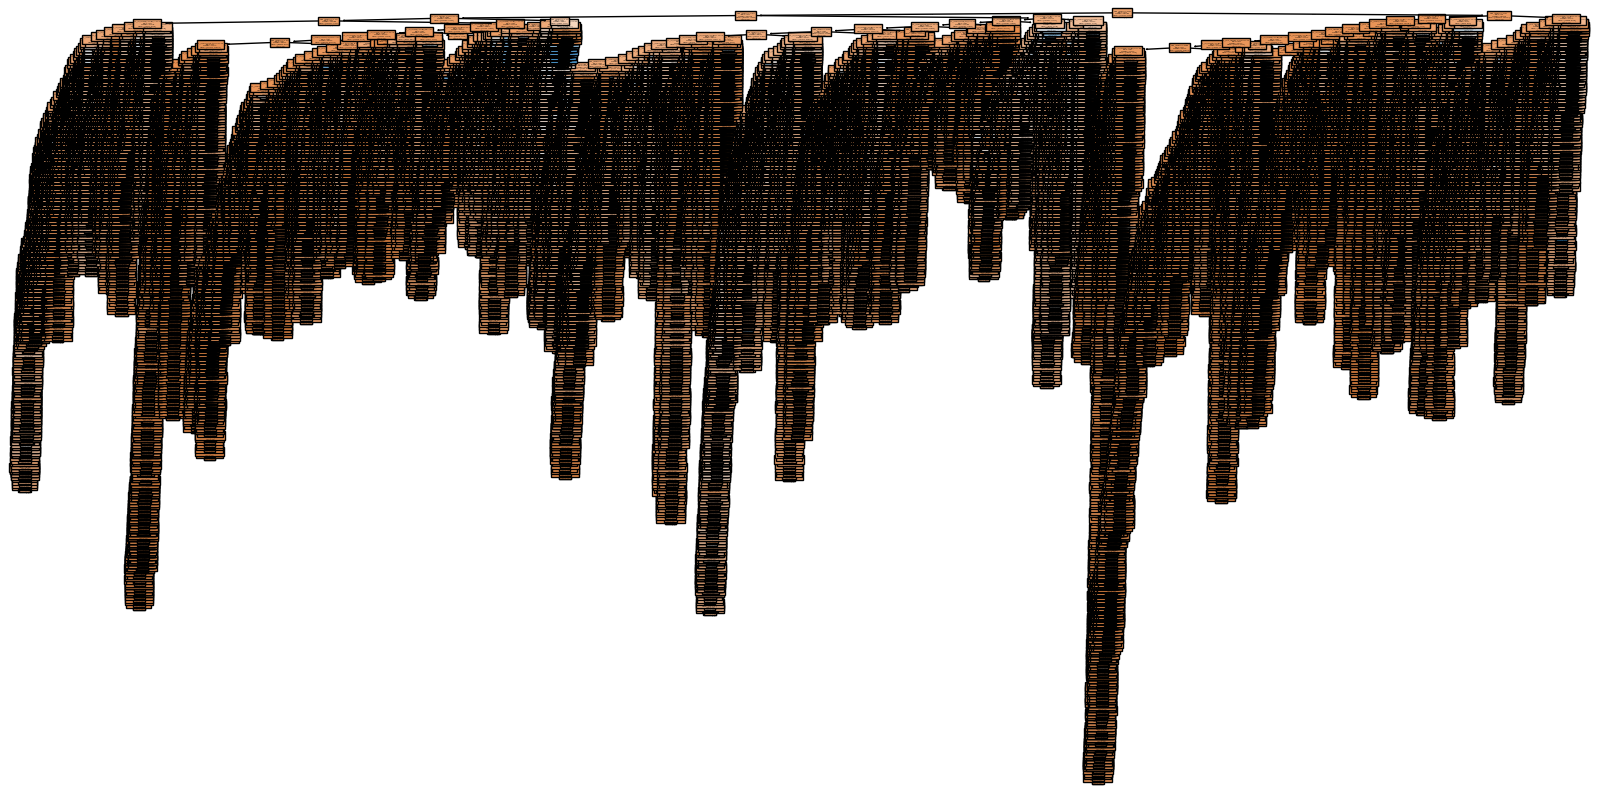

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

# Extract the trained DecisionTreeClassifier
model = pipeDT.named_steps['classifier']

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(model, 
          filled=True, 
          feature_names=pipeDT.named_steps['transformer'].get_feature_names_out(), 
          class_names=True)
plt.show()

### KNN

In [17]:
# Takes too long for dataset size

# Referenced source: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html AND precept 7
from sklearn.neighbors import KNeighborsClassifier

print("KNN CLASSIFIER")
pipeKNN = make_pipeline(preprocessor, KNeighborsClassifier(n_neighbors=2))

print_results(pipeKNN, Xtrain, Xtest, ytrain, ytest)

KNN CLASSIFIER
-----------------TRAINING-----------------


KeyboardInterrupt: 

### SVC

In [ ]:
# Referenced source: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.fit AND precept 7
from sklearn.svm import SVC

print("SUPPORT VECTOR CLASSFIER")
pipeSVC = make_pipeline(StandardScaler(), SVC(kernel='linear', random_state=4))

print_results(pipeSVC, Xtrain, Xtest, ytrain, ytest)

SUPPORT VECTOR CLASSFIER
-----------------TRAINING-----------------


### Random Forest

In [ ]:
# Referenced source: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
from sklearn.ensemble import RandomForestClassifier

print("RANDOM FOREST")
pipeRF = make_pipeline(preprocessor, RandomForestClassifier(random_state=4))

print_results(pipeRF, Xtrain, Xtest, ytrain, ytest)

RANDOM FOREST
-----------------TRAINING-----------------
